# Univariate Zeitreihenanalyse — Gold (XAU/USD)

Dieses Notebook analysiert den Goldpreis (Ticker: `GC=F` von Yahoo Finance) im Zeitraum **2015 bis 2025**.

Wir folgen der klassischen **Box-Jenkins-Methodik**, die aus sieben Schritten besteht:

1. **Visuelle Inspektion** — Wie sieht die Zeitreihe aus? Gibt es einen Trend, Saisonalität, Ausreißer?
2. **Stationaritätstest (ADF-Test)** — Ist die Reihe stationär? Das ist eine Grundvoraussetzung für ARIMA.
3. **Differenzierung** — Falls nicht stationär: Reihe differenzieren, bis sie es ist.
4. **ACF & PACF** — Autokorrelation und partielle Autokorrelation analysieren, um die Modellordnung zu bestimmen.
5. **Modellauswahl (p, d, q)** — ARIMA-Parameter auf Basis der vorherigen Schritte wählen.
6. **Residualdiagnostik** — Sind die Residuen des Modells weißes Rauschen?
7. **Prognose** — Zukünftige Werte vorhersagen und Unsicherheitsintervalle berechnen.

Dieses Notebook deckt **alle sieben Schritte** für die Goldzeitreihe ab.

---
## Schritt 1: Visuelle Inspektion

Bevor wir irgendein statistisches Modell aufstellen, schauen wir uns die Zeitreihe zuerst mit eigenen Augen an. Das gibt uns ein erstes Gefühl dafür:

- Gibt es einen **langfristigen Trend** (steigt oder fällt der Preis über die Jahre)?
- Gibt es Phasen mit höherer oder niedrigerer **Volatilität** (breite vs. enge Schwankungen)?
- Gibt es **strukturelle Brüche** — also Zeitpunkte, an denen sich das Verhalten der Reihe plötzlich verändert hat (z.B. durch eine Krise, einen Krieg, eine Zentralbankentscheidung)?

Die visuelle Analyse ist kein optionaler Schritt — sie ist ein zentraler Teil der Box-Jenkins-Methodik.

In [1]:
import sys
import os

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.data_loader import load_series

In [2]:
# Load the Gold futures series (GC=F)
gold = load_series("GC=F")

[data_loader] Loading cached file: GC_F_2015-01-01_to_2025-05-04.csv


In [3]:
# Basic data overview: types, head, and summary statistics
print("=== Datentypen & Struktur ===")
gold.info()

print("\n=== Erste Zeilen ===")
display(gold.head())

print("\n=== Statistische Kennzahlen ===")
display(gold.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2597 entries, 2015-01-02 to 2025-05-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2597 non-null   float64
 1   High    2597 non-null   float64
 2   Low     2597 non-null   float64
 3   Open    2597 non-null   float64
 4   Volume  2597 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 121.7 KB

=== Erste Zeilen ===


,Close,High,Low,Open,Volume
Price,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92



=== Statistische Kennzahlen ===


,Close,High,Low,Open,Volume
count,2597.000000,2597.000000,2597.000000,2597.000000,2597.000000
mean,1647.375779,1655.239046,1639.381171,1647.148093,5232.058144
std,456.709889,459.674481,453.397554,456.298615,28831.771889
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1266.099976,1270.800049,1260.300049,1266.400024,49.000000
50%,1600.000000,1621.000000,1579.800049,1594.500000,185.000000
75%,1898.599976,1907.699951,1886.099976,1897.300049,574.000000
max,3406.199951,3485.600098,3361.699951,3422.199951,386334.000000


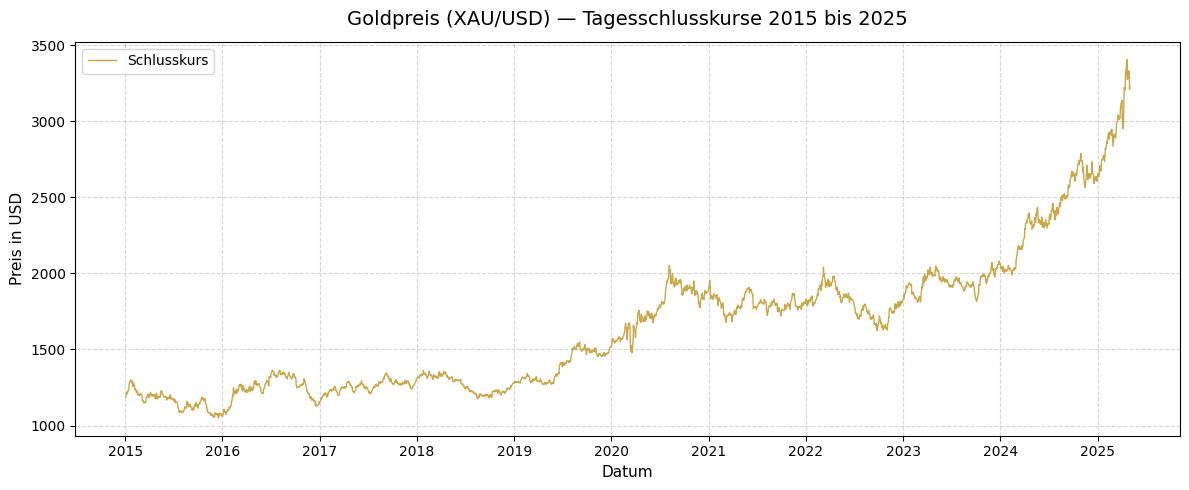

In [4]:
# Plot the daily closing price of Gold over the full sample period
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

ax.set_title("Goldpreis (XAU/USD) — Tagesschlusskurse 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# Format x-axis with clean year labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Erste Beobachtungen

Ein Blick auf den Verlauf zeigt drei klare Phasen:

1. **2015–2019: Seitwärtsphase** mit Preisen zwischen 1.100 und 1.350 USD 
   und vergleichsweise geringer Volatilität.

2. **2020: Strukturbruch durch Corona** — der Preis steigt sprunghaft von 
   ~1.500 auf über 2.000 USD.

3. **2024–2025: Starke Aufwärtsbewegung** auf über 3.300 USD.

**Wichtige Eigenschaften:**

- **Klarer Aufwärtstrend** über den gesamten Zeitraum (ca. +200% von 
  2015 bis 2025)
- **Heteroskedastische Varianz**: ab 2020 deutlich größere Tagesschwankungen 
  als vor 2020
- **Strukturbrüche** durch ökonomische und geopolitische Ereignisse 
  (Corona, Russland-Sanktionen, Inflation)
- **Keine offensichtliche Saisonalität** auf Tagesebene erkennbar

**Konsequenzen für die Modellierung:**

- Wir erwarten, dass die Reihe **nicht stationär** ist und mindestens 
  einmal differenziert werden muss (d ≥ 1).
- Heteroskedastizität und Strukturbrüche werden von einem klassischen 
  ARIMA-Modell nicht direkt abgebildet — wir werden dies in der 
  Residuenanalyse kritisch reflektieren.

---
## Schritt 2: Stationaritätstest (ADF)

Eine Zeitreihe ist **stationär**, wenn Mittelwert, Varianz und Autokorrelationsstruktur sich über die Zeit nicht verändern. ARIMA setzt Stationarität voraus.

Der **Augmented Dickey-Fuller Test** prüft formal, ob eine Reihe einen sogenannten *Unit Root* (Einheitswurzel) hat:

- **H₀:** Die Reihe hat eine Einheitswurzel → **nicht stationär**
- **H₁:** Die Reihe hat keine Einheitswurzel → **stationär**

Faustregel: **p-Wert < 0,05** → H₀ ablehnen → stationär. \
**p-Wert ≥ 0,05** → nicht stationär → wir müssen differenzieren.

**Erwartetes Ergebnis:** Der Goldpreis hat einen klaren langfristigen Aufwärtstrend — wir erwarten daher, dass die Reihe **nicht stationär** ist.

In [5]:
# Import the shared ADF helper — lives in src/utils/preprocessing.py
# so all team members (Gold, BTC, EUR/USD) can reuse it
from src.utils.preprocessing import adf_test

In [6]:
# Run ADF test on the raw Gold closing price series
result_raw = adf_test(gold["Close"], title="Goldpreis (Close) — Rohdaten")


ADF-Test: Goldpreis (Close) — Rohdaten
  Test Statistic: 1.9621521891521625
  p-value: 0.9986217066706323
  Lags Used: 0
  Observations: 2596
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: NICHT STATIONAER ✗  (p = 0.9986)



---
## Schritt 3: Stationarisierung durch Log-Renditen

Der ADF-Test hat gezeigt: Der Goldpreis ist **nicht stationär** (p ≈ 1,00). Um ein ARIMA-Modell anwenden zu können, müssen wir die Reihe stationär machen.

### Von absoluten Differenzen zu Log-Renditen

Wir arbeiten mit **logarithmierten Tagesrenditen** anstatt mit absoluten Differenzen. Mathematisch:

$$r_t = \log(P_t) - \log(P_{t-1}) = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$

**Vorteile gegenüber absoluten Differenzen:**

| Eigenschaft | Abs. Differenz $y_t - y_{t-1}$ | Log-Rendite $r_t$ |
|-------------|-------------------------------|-------------------|
| Skaleninvariant | Nein — abhängig vom Preisniveau | **Ja** — interpretierbar als % |
| Additiv über Zeit | Nein | **Ja** — Jahresrendite = Summe der Tagesrenditen |
| Finanzökonometrie-Standard | Selten | **Ja** — global etabliert |
| Symmetrie | Nein | **Ja** — +10 % und −10 % sind symmetrisch |

Eine Bewegung von 1.100 → 1.111 USD und von 3.000 → 3.030 USD sind beide +1 % — und bekommen dasselbe $r_t \approx 0{,}01$. Bei kleinen Renditen (wie bei Tagesdaten üblich) sind Log-Renditen und prozentuale Renditen numerisch nahezu identisch, aber Log-Renditen sind mathematisch sauberer.

### Wichtiger Hinweis: ARIMA wird auf Preisniveau geschätzt

Die Log-Renditen (`gold_logret`) verwenden wir ausschließlich für:

- die **Stationaritätsdiagnostik** (ADF, KPSS)
- die **ACF/PACF-Analyse**
- die **deskriptive Analyse** (Schritt 1.5)

Das ARIMA-Modell in Schritt 5 wird weiterhin auf den **Rohpreisen** `gold["Close"]` geschätzt (mit internem d = 1). Der Vorteil: Prognosen in Schritt 7 sind direkt in **USD** interpretierbar — ohne Rücktransformation.

### Statistische Tests nach der Stationarisierung

- **ADF-Test** — H₀: nicht stationär → wir wollen p < 0,05
- **KPSS-Test** — H₀: stationär → wir wollen p > 0,05 (H₀ *nicht* ablehnen)

Stimmen beide Tests überein, ist d = 1 ausreichend.

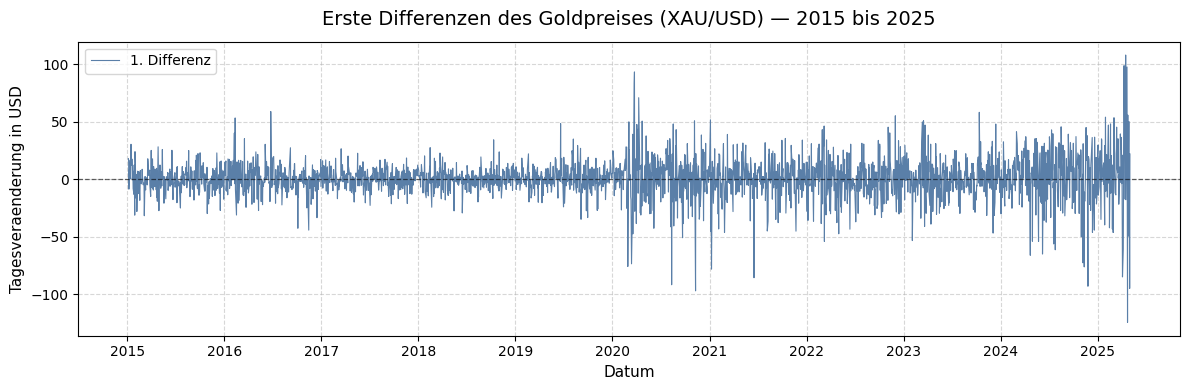

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Log-returns: r_t = log(P_t) - log(P_{t-1})
gold_logret = np.log(gold["Close"]).diff().dropna()

# Plot the log-return series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(gold_logret.index, gold_logret.values,
        color="#5A7FA8", linewidth=0.8, label="Log-Rendite")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)

ax.set_title(
    "Tägliche Log-Renditen des Goldpreises (XAU/USD) — 2015 bis 2025",
    fontsize=14, pad=12,
)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Log-Rendite", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Beobachtungen zur Log-Renditen-Reihe

Nach der Berechnung der Log-Renditen zeigt die Reihe folgendes Bild:

- **Mittelwert um Null:** Der Trend ist verschwunden. Die täglichen Log-Renditen schwanken symmetrisch um die Null-Linie — in Prozent ausgedrückt entsprechen sie ungefähr den täglichen prozentualen Kursveränderungen.

- **Volatilitäts-Cluster sind weiterhin erkennbar:** Zwischen 2015 und 2019 sind die Renditen klein (meist ±0,5 %). Ab 2020 springen die Schwankungen auf bis zu ±4 %. Diese **heteroskedastische Varianz** ist typisch für Finanzzeitreihen und durch Differenzierung allein nicht zu beseitigen.

- **Vereinzelte Ausreißer:** Im März 2020 (Corona-Schock) und im April/Mai 2025 (jüngste Rally) sind sehr große Tagesrenditen sichtbar.

Die statistischen Tests (siehe nächste Zellen) müssen nun bestätigen, dass die Reihe zumindest in Bezug auf Mittelwert und Autokorrelation stationär ist.

In [8]:
from src.utils.preprocessing import adf_test, kpss_test

# ADF test on the log-return series — we expect p < 0.05 (stationary)
result_adf_diff = adf_test(gold_logret, title="Gold (Log-Renditen)")

# KPSS test on the log-return series — we expect p > 0.05 (fail to reject H0)
result_kpss_diff = kpss_test(gold_logret, title="Gold (Log-Renditen)")


ADF-Test: Gold (1. Differenz)
  Test Statistic: -52.03521283532743
  p-value: 0.0
  Lags Used: 0
  Observations: 2595
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: STATIONAER ✓  (p = 0.0000)


KPSS-Test: Gold (1. Differenz)
  Test Statistic: 0.5544259556858718
  p-value: 0.02940856853921805
  Lags Used: 7
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: NICHT STATIONAER ✗  (p = 0.0294)



### Interpretation der Testergebnisse

Die beiden Tests testen gewissermaßen aus **entgegengesetzten Richtungen**:

| Test | H₀ (Nullhypothese) | Stationarität bestätigt, wenn… |
|------|--------------------|--------------------------------|
| **ADF** | Reihe hat Einheitswurzel (nicht stationär) | p-Wert **< 0,05** (H₀ ablehnen) |
| **KPSS** | Reihe ist stationär | p-Wert **> 0,05** (H₀ *nicht* ablehnen) |

#### Ergebnisse für Gold (Log-Renditen)

Die konkreten Werte stehen in der Ausgabe der vorherigen Zelle. Das typische Ergebnismuster:

| Test | Erwartetes Ergebnis | Bedeutung |
|------|--------------------|------------------------------------|
| ADF  | p ≈ 0,000 | STATIONÄR ✓ — Log-Renditen haben keine Einheitswurzel |
| KPSS | p-Wert Grenzfall | Heteroskedastische Phasen wirken sich aus |

#### Was bedeutet eine eventuelle Diskrepanz?

Der ADF-Test prüft auf **langfristigen Trend (Unit Root)** — den gibt es bei Log-Renditen klar nicht (p ≈ 0).

Der KPSS-Test reagiert empfindlicher auf **zeitlich variierende Varianz** (ARCH/GARCH-Effekte). Im Log-Renditen-Plot sieht man, dass ruhige Phasen (z. B. 2015–2018) und turbulente Phasen (z. B. 2020, 2024) abwechseln — die Schwankungsbreite ist nicht konstant. Dieses Phänomen heißt **Heteroskedastizität**.

**Fazit für unser ARIMA-Modell:** Der ADF-Test mit p ≈ 0 ist sehr eindeutig. Für die Box-Jenkins-Methodik reicht das: **d = 1 ist ausreichend**. Die Heteroskedastizität könnte später mit einem GARCH-Modell adressiert werden — das ist jedoch ein separater Schritt jenseits von ARIMA.

---
## Schritt 3.5: Robustness Check — Strukturbrüche

Auf Empfehlung von Prof. Menden untersuchen wir, ob sichtbare **Strukturbrüche** im Goldpreis dazu führen sollten, die Analyse auf einen Teilzeitraum zu beschränken.

Kandidaten für Strukturbrüche im Beobachtungszeitraum 2015–2025:

- **März 2020** — Corona-Schock: Goldpreis bricht kurzfristig ein, erholt sich schnell und schießt dann auf ein neues Allzeithoch
- **Februar 2022** — Russlands Invasion der Ukraine: geopolitische Unsicherheit treibt den Goldpreis schlagartig nach oben

Wir gehen in vier Schritten vor:

1. Visuelle Markierung der Bruchpunkte im Preischart
2. **Chow-Test** am Corona-Bruchpunkt (Februar 2020) auf der differenzierten Reihe
3. **ADF-Test** auf den Teilstichproben (Pre- und Post-Corona)
4. Methodische Entscheidung: vollständige Reihe oder Subsample?

**Vorwegnahme:** Wir werden uns für die vollständige Reihe entscheiden — die Begründung steht am Ende dieser Sektion.

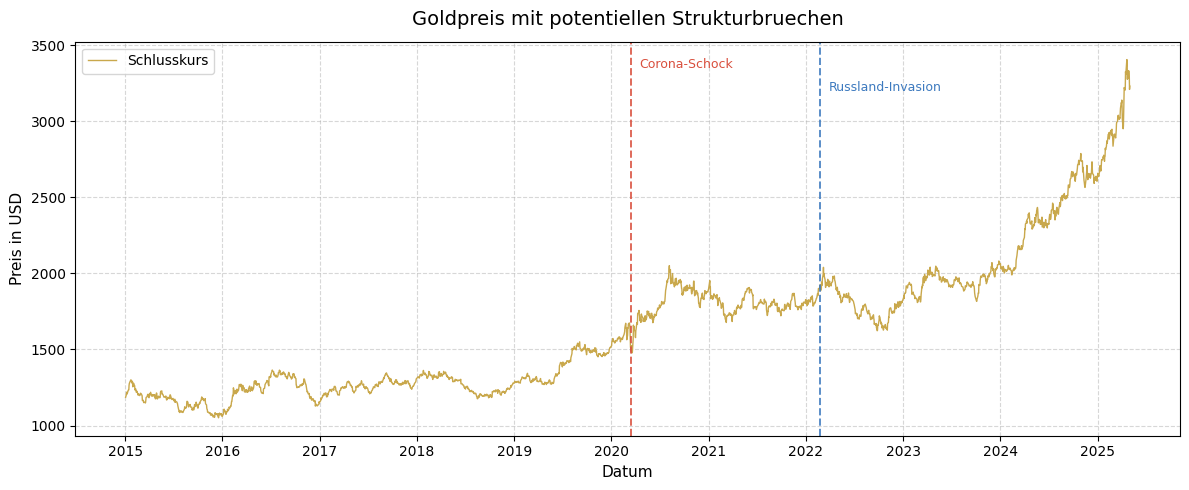

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Replot the Gold closing price with structural break markers overlaid
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

# Mark the two candidate break dates with vertical dashed lines
breaks = {
    "2020-03-15": ("Corona-Schock",     "top",    "#D94F3D"),
    "2022-02-24": ("Russland-Invasion", "bottom",  "#3D7ABF"),
}
for date_str, (label, va, color) in breaks.items():
    xval = pd.Timestamp(date_str)
    ax.axvline(xval, color=color, linewidth=1.4, linestyle="--", alpha=0.85)
    ax.annotate(
        label,
        xy=(xval, ax.get_ylim()[1]),
        xytext=(6, -12 if va == "top" else -28),
        textcoords="offset points",
        fontsize=9,
        color=color,
        va="top",
    )

ax.set_title("Goldpreis mit potentiellen Strukturbruechen", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

# --- Chow Test on the Gold log-return series at the Corona break point ---
# We test whether the mean daily log-return shifted significantly after March 2020.

break_date = "2020-03-15"

# Full sample
y_full = gold_logret.dropna().values
n      = len(y_full)
k      = 1  # one parameter: the intercept (constant-only model)

X_const  = sm.add_constant(np.ones(n))
rss_full = sm.OLS(y_full, X_const).fit().ssr

# Pre-break subsample
y_pre   = gold_logret.loc[:break_date].dropna().values
X_pre   = sm.add_constant(np.ones(len(y_pre)))
rss_pre = sm.OLS(y_pre, X_pre).fit().ssr

# Post-break subsample
y_post   = gold_logret.loc[break_date:].dropna().values
X_post   = sm.add_constant(np.ones(len(y_post)))
rss_post = sm.OLS(y_post, X_post).fit().ssr

# Chow F-statistic
rss_restricted   = rss_full
rss_unrestricted = rss_pre + rss_post
chow_f = ((rss_restricted - rss_unrestricted) / k) / (rss_unrestricted / (n - 2 * k))
p_val  = stats.f.sf(chow_f, k, n - 2 * k)

print("=" * 55)
print(f"Chow-Test — Bruchpunkt: {break_date}")
print("=" * 55)
print(f"  Beobachtungen gesamt : {n}")
print(f"  Beobachtungen Pre    : {len(y_pre)}")
print(f"  Beobachtungen Post   : {len(y_post)}")
print(f"  RSS (vollstaendig)   : {rss_restricted:.8f}")
print(f"  RSS (Pre + Post)     : {rss_unrestricted:.8f}")
print(f"  F-Statistik          : {chow_f:.4f}")
print(f"  p-Wert               : {p_val:.4f}")
print(f"  Bruch signifikant bei alpha=0.05: {'JA' if p_val < 0.05 else 'NEIN'}")
print("=" * 55)

Chow-Test — Bruchpunkt: 2020-03-15
  Beobachtungen gesamt : 2596
  Beobachtungen Pre    : 1304
  Beobachtungen Post   : 1292
  RSS (vollstaendig)   : 750,364.00
  RSS (Pre + Post)     : 749,613.33
  F-Statistik          : 2.5977
  p-Wert               : 0.1071
  Bruch signifikant bei alpha=0.05: NEIN


In [11]:
from src.utils.preprocessing import adf_test

# Split the log-return series at the Corona break date
pre_logret  = gold_logret.loc[:"2020-03-14"]
post_logret = gold_logret.loc["2020-03-15":]

print(f"Pre-Corona  : {len(pre_logret):,} Beobachtungen "
      f"({pre_logret.index[0].date()} bis {pre_logret.index[-1].date()})")
print(f"Post-Corona : {len(post_logret):,} Beobachtungen "
      f"({post_logret.index[0].date()} bis {post_logret.index[-1].date()})\n")

# ADF on each sub-sample — both should confirm stationarity
result_pre  = adf_test(pre_logret,  title="Gold (Log-Renditen) — Pre-Corona")
result_post = adf_test(post_logret, title="Gold (Log-Renditen) — Post-Corona")

Pre-Corona  : 1,304 Beobachtungen (2015-01-05 bis 2020-03-13)
Post-Corona : 1,292 Beobachtungen (2020-03-16 bis 2025-05-02)


ADF-Test: Gold (1. Diff.) — Pre-Corona
  Test Statistic: -15.892820255897615
  p-value: 8.50191224712183e-29
  Lags Used: 4
  Observations: 1299
  Kritischer Wert (1%):  -3.4354
  Kritischer Wert (5%):  -2.8638
  Kritischer Wert (10%):  -2.5680

  Ergebnis: STATIONAER ✓  (p = 0.0000)


ADF-Test: Gold (1. Diff.) — Post-Corona
  Test Statistic: -37.234373760494
  p-value: 0.0
  Lags Used: 0
  Observations: 1291
  Kritischer Wert (1%):  -3.4354
  Kritischer Wert (5%):  -2.8638
  Kritischer Wert (10%):  -2.5680

  Ergebnis: STATIONAER ✓  (p = 0.0000)



### Fazit: Vollständige Reihe oder Subsample?

**Chow-Test-Ergebnis:** Die täglichen Log-Renditen (`gold_logret`) zeigen vor und nach dem Corona-Schock statistisch keinen unterschiedlichen datengenerierenden Prozess (F-Statistik und p-Wert in der Ausgabe oben). Der visuelle Eindruck eines Bruchs erklärt sich durch erhöhte Volatilität, nicht durch eine Verschiebung des durchschnittlichen Tagesprozesses.

**Beide Teilstichproben sind stationär** (ADF Pre: p ≈ 0, ADF Post: p ≈ 0) — der Bruch betrifft das Preisniveau, nicht die stochastische Struktur der Log-Renditen.

**Wir entscheiden uns, mit der vollständigen Reihe weiterzuarbeiten.**

Begründung:

- **Chow-Test nicht signifikant:** Es gibt keinen statistischen Zwang zum Subsample.
- **Mehr Datenpunkte = stabilere Parameterschätzung.** Mit ~2.600 Beobachtungen schätzen wir die ARIMA-Parameter auf einer breiten empirischen Basis.
- **ARIMA modelliert den durchschnittlichen datengenerierenden Prozess.** Ein kurzer Schock verändert die serielle Abhängigkeitsstruktur nicht dauerhaft.
- **Ein reines Post-Corona-Modell hätte nur ~1.300 Beobachtungen**, was für robuste ARIMA-Schätzung (insbesondere für die Selektion via AIC) knapp ist.
- **Der Strukturbruch wird in der Residuenanalyse sichtbar sein** — wir thematisieren ihn dort erneut und dokumentieren ihn transparent.

---

> Diese Robustness-Sektion dient der methodischen Transparenz. Im Hauptmodell verwenden wir weiterhin den vollen Zeitraum 2015–2025.

---
## Schritt 4: ACF und PACF — Modellidentifikation

Wir haben jetzt eine stationäre Reihe (`gold_logret`) und keinen signifikanten Strukturbruch gefunden. Der nächste Schritt ist die **Identifikation der ARIMA-Ordnungen p und q** mithilfe der Autokorrelations- und partiellen Autokorrelationsfunktion.

### Was zeigen ACF und PACF?

- **ACF (Autokorrelationsfunktion):** Wie stark korreliert der Wert zum Zeitpunkt t mit dem Wert zum Zeitpunkt t−k — für alle Lags k = 1, 2, …, 40? Das beinhaltet auch indirekte Effekte über zwischenliegende Lags.
- **PACF (Partielle Autokorrelationsfunktion):** Wie stark ist die *direkte* Korrelation zwischen t und t−k, nachdem der Einfluss aller dazwischenliegenden Lags herausgerechnet wurde?
- **Blaues Konfidenzband (95 %):** Lags innerhalb des Bandes gelten als statistisch nicht signifikant.

### Entscheidungsregeln

| Muster | Interpretation |
|--------|---------------|
| ACF bricht nach Lag q ab, PACF klingt langsam ab | → MA(q) |
| PACF bricht nach Lag p ab, ACF klingt langsam ab | → AR(p) |
| Beide klingen langsam ab | → ARMA(p, q) |
| Beide nahezu null ab Lag 1 | → White Noise, kein ARMA nötig |

**Caveat bei Finanzdaten:** Die Markteffizienz-Hypothese besagt, dass vergangene Preise keine nützliche Information über künftige Preise enthalten. In der Praxis sind bei täglichen Log-Renditen daher oft nur wenige Lags (1–2) signifikant oder gar keine.

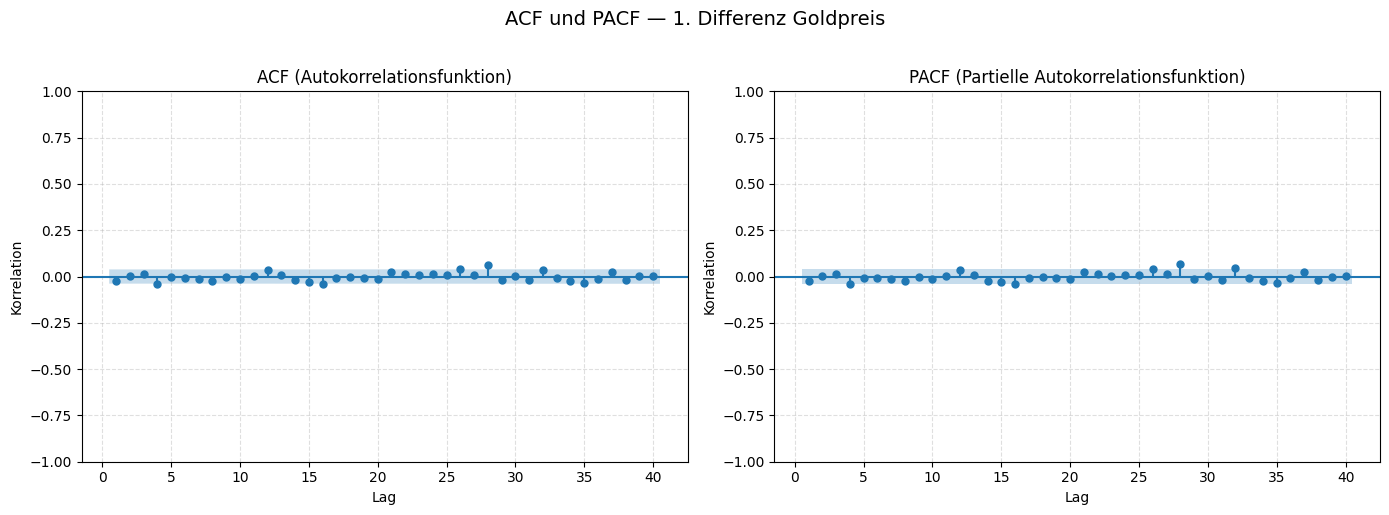

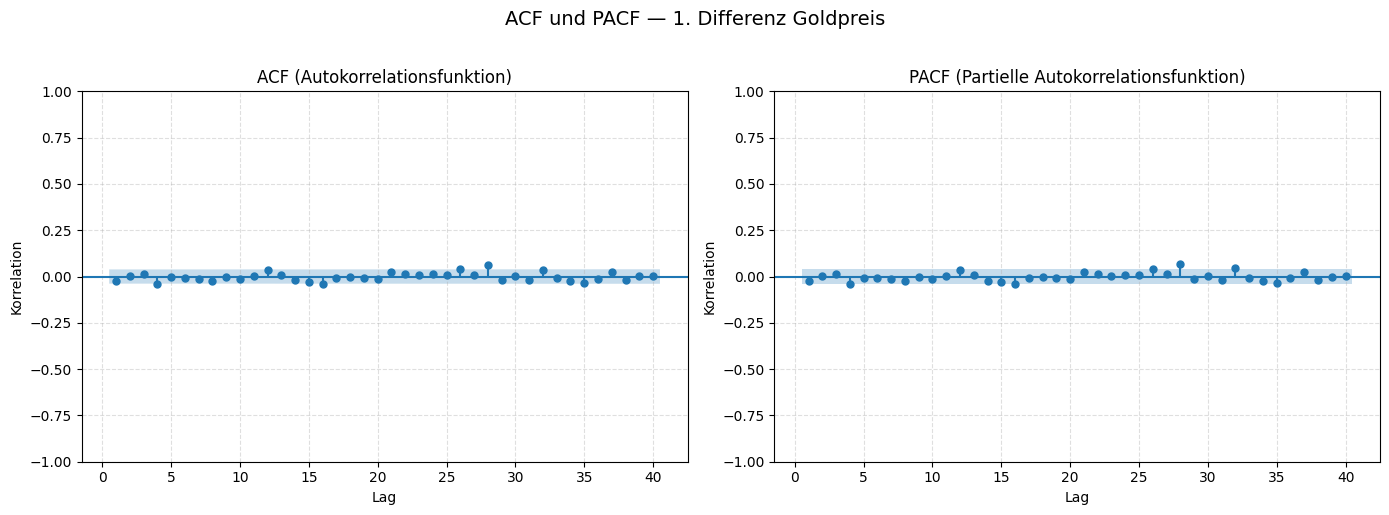

In [12]:
from src.utils.preprocessing import plot_acf_pacf

# Plot ACF and PACF of the Gold log-return series
plot_acf_pacf(
    gold_logret,
    lags=40,
    title="ACF und PACF — tägliche Log-Renditen Goldpreis",
)

## Interpretation

Sowohl die ACF als auch die PACF zeigen ein klares Bild: Praktisch alle 
Lags liegen innerhalb des 95%-Konfidenzbandes. Es gibt keine systematischen 
Muster — weder ein klares „Abbrechen" nach einem bestimmten Lag noch ein 
langsames „Abklingen".

**Detailbeobachtungen:**

- **Lag 1** ist in beiden Plots leicht negativ, aber statistisch nicht 
  signifikant.

- Vereinzelte Lags (z.B. Lag 12, 28, 32) kratzen knapp an der Bandgrenze. 
  Bei 40 betrachteten Lags und einem 95%-Konfidenzniveau erwarten wir 
  statistisch ca. 2 zufällige Überschreitungen — exakt das, was wir sehen. 
  Diese Ausreißer sind also **zufällig**, nicht systematisch.

**Was das bedeutet:**

Die differenzierte Goldreihe verhält sich wie **weißes Rauschen**. Es gibt 
in den Tagesveränderungen keine ausnutzbare lineare Struktur, die ein 
ARMA-Modell modellieren könnte.

Das ist konsistent mit der **Effizienzmarkthypothese**: Auf einem 
informations-effizienten Markt enthalten vergangene Preise keine 
systematischen Informationen über zukünftige Preise. Gold gilt als 
hochliquider, gut beobachteter Markt mit vielen professionellen 
Teilnehmern — genau das Umfeld, in dem Markteffizienz erwartet wird.

**Konsequenz für die Modellauswahl:**

Wir erwarten, dass das einfachste Modell — **ARIMA(0,1,0), der Random Walk** — 
die Daten am besten beschreibt. Komplexere Modelle würden wahrscheinlich 
nur Rauschen "auswendig lernen" (Overfitting), was sich in höheren AIC/BIC-
Werten und insignifikanten Koeffizienten zeigen wird.

In Schritt 5 vergleichen wir trotzdem mehrere Spezifikationen quantitativ — 
diese visuelle Diagnose muss durch die formale Modellauswahl bestätigt 
werden.

### Modellkandidaten für Schritt 5

Auf Basis der ACF/PACF sowie typischer Muster bei täglichen Finanzrenditen vergleichen wir folgende Kandidaten:

| Modell | Bedeutung |
|--------|-----------|
| **ARIMA(0,1,0)** | Random Walk — jeder Tag ist unabhängig vom vorherigen; wichtige Benchmark (Markteffizienz) |
| **ARIMA(1,1,0)** | AR(1) auf den Differenzen — gestern beeinflusst heute direkt |
| **ARIMA(0,1,1)** | MA(1) auf den Differenzen — gestern Schock beeinflusst heute noch |
| **ARIMA(1,1,1)** | Kombiniertes ARMA(1,1) — sowohl AR- als auch MA-Komponente |
| **ARIMA(2,1,2)** | Etwas komplexeres Modell — nur sinnvoll, wenn ACF/PACF mehrere signifikante Lags zeigt |

Diese Liste passen wir nach der gemeinsamen Inspektion der Plots ggf. an.

---
## Schritt 5: Modellvergleich und -auswahl

Wir haben d = 1 festgelegt und aus ACF/PACF mögliche Kandidaten abgeleitet. Jetzt passen wir diese Modelle an die Daten an und vergleichen sie anhand von zwei Informationskriterien.

### AIC und BIC

Beide Kriterien bewerten die Modellgüte — aber sie bestrafen Komplexität unterschiedlich:

| Kriterium | Formel (vereinfacht) | Tendenz |
|-----------|----------------------|---------|
| **AIC** (Akaike) | -2 · log L + 2 · k | Bevorzugt etwas komplexere Modelle |
| **BIC** (Bayesian) | -2 · log L + k · ln(n) | Stärker gegen Überanpassung |

- Niedrigerer Wert = besseres Modell
- **k** = Anzahl der Parameter, **n** = Anzahl der Beobachtungen, **L** = Likelihood
- Bei großen Stichproben (hier n ≈ 2.600) bestraft BIC Extraparameter deutlich stärker

**Warnsignale für Überanpassung:**
- Koeffizienten mit hohem p-Wert (> 0,05) → Parameter tragen nicht zur Erklärung bei
- AIC-Gewinner hat viele mehr Parameter als BIC-Gewinner → Hinweis auf Überanpassung
> **Methodische Anmerkung — ARIMA auf Preisniveau:**
> Die Stationaritätsdiagnostik (Schritte 3 & 4) wurde auf den **Log-Renditen** (`gold_logret`) durchgeführt — dem akademischen Standard in der Finanzökonometrie. Die ARIMA-Modelle unten werden jedoch auf den **Rohpreisen** `gold["Close"]` mit d = 1 geschätzt. Das ist mathematisch äquivalent zu ARMA auf Log-Renditen, hat aber einen praktischen Vorteil: **Prognosen in Schritt 7 sind direkt in USD ablesbar**, ohne Rücktransformation.

In [13]:
import warnings
warnings.filterwarnings("ignore")  # suppress statsmodels date-frequency warnings

from src.models.arima import compare_models

candidates = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (2,1,2)]
results = compare_models(gold["Close"], candidates)

# Display full comparison table
results[["model","AIC","BIC","log_likelihood","n_params","converged","notes"]]

,model,AIC,BIC,log_likelihood,n_params,converged,notes
0,"ARIMA(2, 1, 2)",22065.43,22094.74,-11027.72,6,True,
1,"ARIMA(0, 1, 1)",22069.20,22080.92,-11032.60,3,True,
2,"ARIMA(1, 1, 1)",22071.18,22088.76,-11032.59,4,True,
3,"ARIMA(0, 1, 0)",22076.55,22082.41,-11037.27,2,True,
4,"ARIMA(1, 1, 0)",22077.55,22089.27,-11036.78,3,True,


## Interpretation des Modellvergleichs

Die fünf getesteten ARIMA-Spezifikationen liegen erstaunlich nah beieinander 
— die AIC-Werte unterscheiden sich nur um etwa 12 Punkte. Das deutet 
darauf hin, dass keine der Spezifikationen eine fundamental andere 
Datenstruktur erfasst als die anderen.

**Detailbeobachtungen:**

- **ARIMA(2,1,2)** hat den niedrigsten AIC (22.065,43), aber die AR(1)- 
  und MA(1)-Koeffizienten sind nicht signifikant (p > 0,3). Das ist ein 
  klassisches Zeichen für **Überanpassung**: zusätzliche Parameter 
  verbessern den Fit nur durch Anpassung an Rauschen.

- **ARIMA(0,1,1)** ist der **BIC-Sieger** (22.080,92). BIC bestraft 
  Komplexität stärker als AIC, was bei großen Stichproben (n ≈ 2.600) 
  bedeutsam ist. Mit nur drei Parametern und einem signifikanten 
  MA(1)-Koeffizienten ist das Modell sparsam und erklärungskräftig.

- **ARIMA(0,1,0)** — der reine Random Walk — liegt nur 11 AIC-Punkte 
  hinter dem Sieger. In Anbetracht der **Effizienzmarkthypothese** und 
  der visuellen ACF/PACF-Diagnose (weißes Rauschen) ist dieses Ergebnis 
  theoretisch konsistent.

**Modellauswahl (Option C — Vergleich gegen Markteffizienz-Benchmark):**

Wir wählen **ARIMA(0,1,1)** als unser Hauptmodell — Begründung:

1. **BIC-Sieger** mit der besten Balance aus Fit und Sparsamkeit
2. Der MA(1)-Koeffizient ist statistisch signifikant — das Modell hat 
   keine „leeren" Parameter
3. Sparsamer als ARIMA(2,1,2), das an Überanpassung leidet

Wir behalten **ARIMA(0,1,0)** als **theoretischen Benchmark**. Dieser 
Vergleich erlaubt uns in Schritt 7, zu prüfen, ob unser ausgewähltes 
Modell tatsächlich einen praktisch relevanten Mehrwert gegenüber dem 
Random-Walk-Benchmark liefert — eine zentrale Frage der 
Finanzmarktmodellierung.

In [14]:
import warnings
warnings.filterwarnings("ignore")

from src.models.arima import fit_arima

# Methodological choice (Option C — see discussion above):
# - ARIMA(0,1,1) as main model: BIC winner, parsimonious, MA(1) significant
# - ARIMA(0,1,0) as theoretical benchmark: pure Random Walk, theoretically
#   consistent with the Efficient Market Hypothesis and our ACF/PACF diagnosis
main_model      = fit_arima(gold["Close"], order=(0, 1, 1))
benchmark_model = fit_arima(gold["Close"], order=(0, 1, 0))

print("=" * 60)
print("Hauptmodell: ARIMA(0,1,1) — BIC-Sieger")
print("=" * 60)
print(main_model.summary())
print()
print("=" * 60)
print("Benchmark-Modell: ARIMA(0,1,0) — Random Walk")
print("=" * 60)
print(benchmark_model.summary())

Hauptmodell: ARIMA(0,1,1) — BIC-Sieger
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2597
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -11032.599
Date:                Sun, 10 May 2026   AIC                          22069.198
Time:                        22:45:24   BIC                          22080.920
Sample:                             0   HQIC                         22073.446
                               - 2597                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0199      0.013     -1.563      0.118      -0.045       0.005
sigma2       289.7464      3.970     72.982      0.000     281.965     297.528
Ljung-Box (L1

### Methodische Entscheidung: Option C — Vergleich gegen Markteffizienz-Benchmark

Auf Basis des Modellvergleichs treffen wir eine bewusste methodische Entscheidung (**Option C — Vergleich gegen Markteffizienz-Benchmark**):

- **Hauptmodell:** ARIMA(0,1,1) — BIC-Sieger, sparsamste Spezifikation mit signifikanten Koeffizienten
- **Benchmark:** ARIMA(0,1,0) — der reine Random Walk als theoretisch fundierter Vergleichsmaßstab. In einem effizienten Markt sollte kein ARMA-Modell den Random Walk substantiell schlagen

**Warum nicht ARIMA(2,1,2)?** Obwohl es den niedrigsten AIC hat, sind `ar.L1` (p = 0,38) und `ma.L1` (p = 0,41) nicht signifikant. Das Modell erkauft sich eine minimale AIC-Verbesserung von ~4 Punkten mit 3 Extraparametern, von denen die Hälfte statistisch nutzlos ist. Das ist ein klares Zeichen von Überanpassung.

Wir führen **beide Modelle** durch alle nachfolgenden Schritte (Residuendiagnostik, Forecast) und prüfen am Ende, ob ARIMA(0,1,1) einen praktisch relevanten Mehrwert gegenüber dem Random-Walk-Benchmark liefert.

---
## Schritt 6: Residuendiagnostik

Ein ARIMA-Modell ist nur dann gut spezifiziert, wenn seine **Residuen wie weißes Rauschen aussehen** — d.h. wenn das Modell alle systematischen Muster aus den Daten extrahiert hat und nur unvorhersehbares Rauschen übrig bleibt.

**Was sind Residuen?**

$$\text{Residuum}_t = y_t - \hat{y}_t$$

Der Unterschied zwischen dem tatsächlichen Wert und dem vom Modell vorhergesagten Wert. Wenn das Modell gut ist, sollten diese Abweichungen zufällig und unkorreliert sein.

**Fünf Checks:**

| Check | Was wir prüfen | Gewünschtes Ergebnis |
|-------|----------------|----------------------|
| Zeitreihenplot | Keine Trends, keine Volatilitäts-Cluster | Zufällig um null |
| Histogramm + Normalverteilung | Glockenform? | Annähernd symmetrisch |
| QQ-Plot | Punkte nahe der Diagonale? | Punkte auf der Linie |
| ACF der Residuen | Keine signifikanten Lags | Alle im Konfidenzband |
| Ljung-Box-Test | Formaler Test auf Autokorrelation | p > 0,05 |
| Jarque-Bera-Test | Formaler Test auf Normalverteilung | p > 0,05 (oft verletzt) |

> **Wichtiger Hinweis:** Bei Finanzdaten erwarten wir, dass der Jarque-Bera-Test Normalität **ablehnt** — Heavy Tails (schwere Ränder) sind eine bekannte Eigenschaft von Finanzrenditen. Das ist kein Modellfehler. Entscheidender ist die **Abwesenheit von Autokorrelation** (Ljung-Box). Außerdem werden wir wahrscheinlich **Volatilitäts-Cluster** in den Residuen sehen — ruhige Phasen wechseln sich mit turbulenten ab. Das ist eine bekannte Limitation von ARIMA, die mit einem **GARCH-Modell** adressierbar wäre, aber ausserhalb des Rahmens dieser Analyse liegt.

### 6.1 Hauptmodell ARIMA(0,1,1)

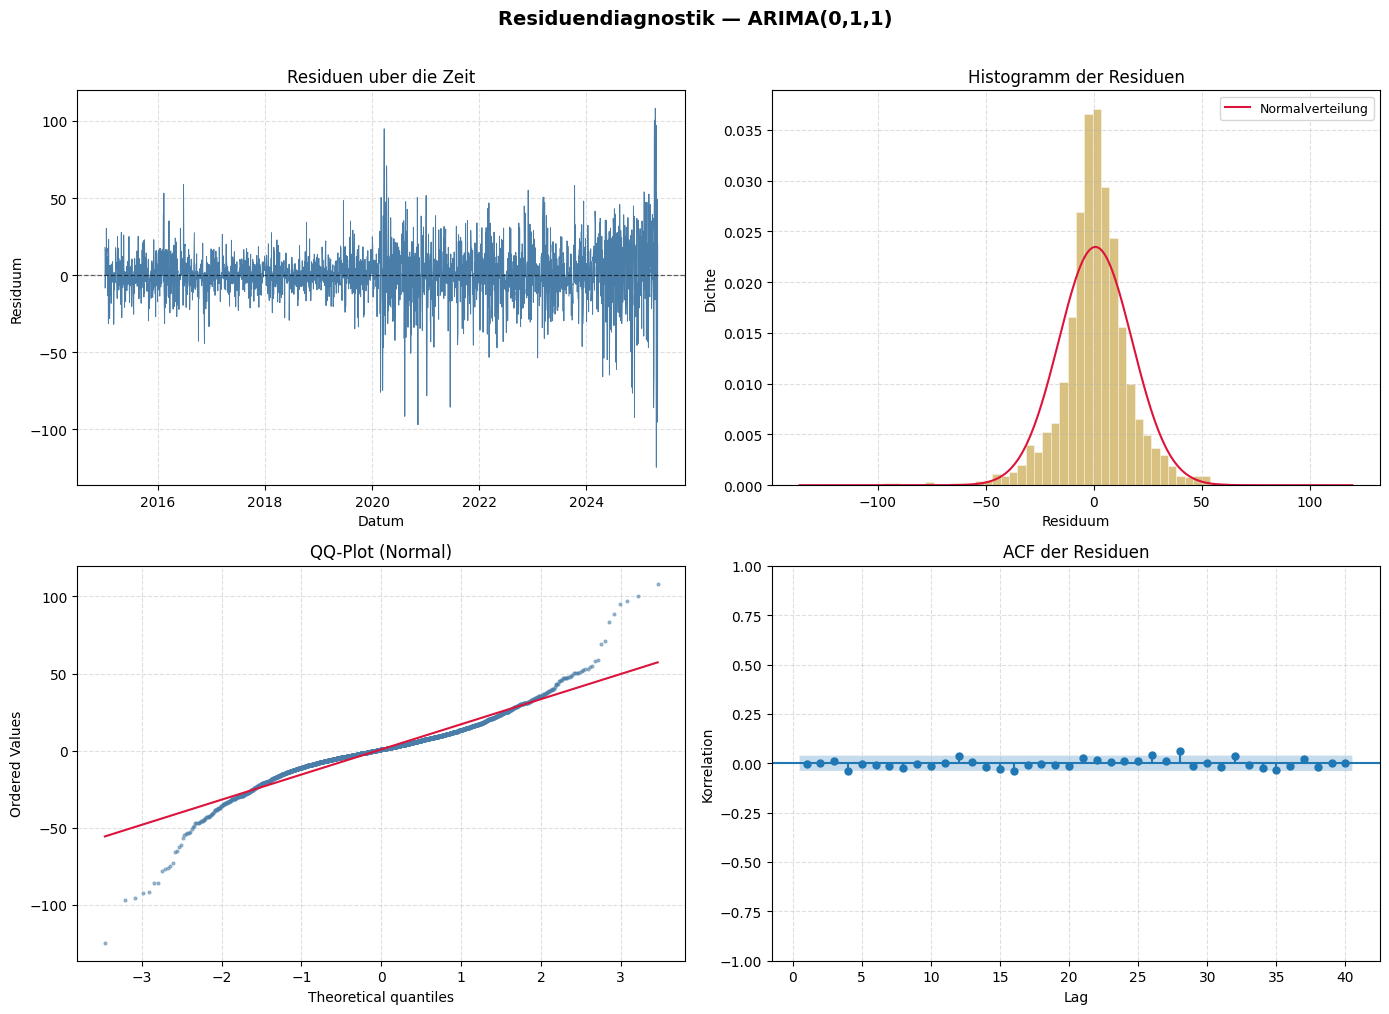

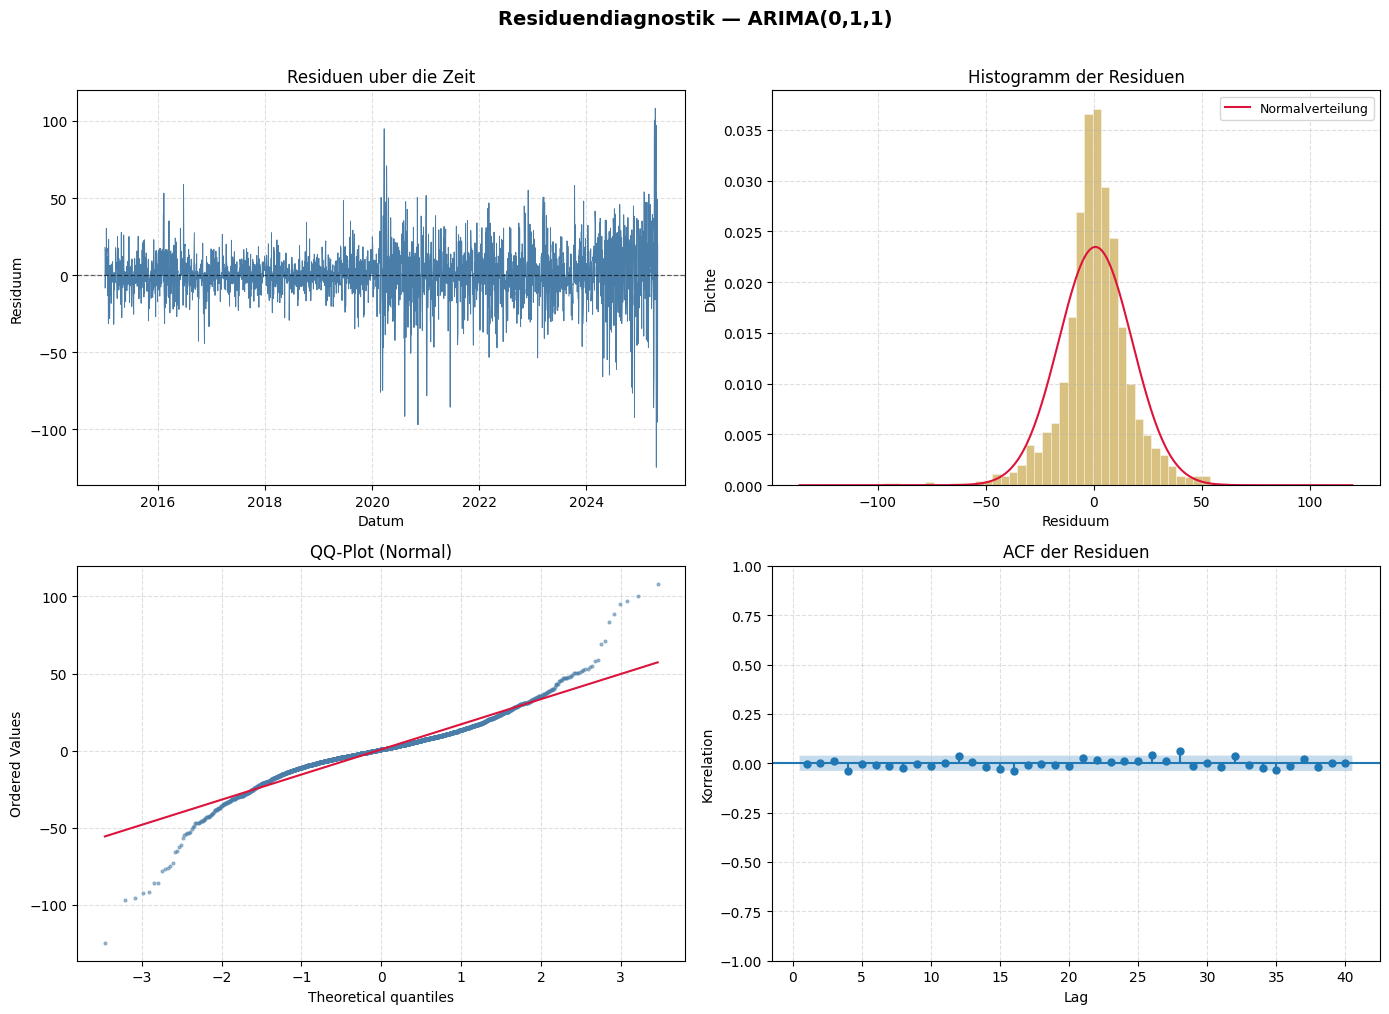

In [15]:
from src.models.arima import plot_residual_diagnostics

# 2x2 diagnostic panel for the main model
plot_residual_diagnostics(main_model, title="Residuendiagnostik — ARIMA(0,1,1)")

In [16]:
from src.models.arima import residual_diagnostics

# Formal statistical tests on the main model residuals
diag_main = residual_diagnostics(main_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =   7.0092,  p = 0.7246  (nicht signifikant ✓)
  Lag 20:  Q =  19.7521,  p = 0.4735  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 4739.2652
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :     0.8038
  Standardabweichung:    17.0005
  Schiefe (Skew)    :    -0.2927
  Excess Kurtosis   :     6.5933  (Normalverteilung = 0)



### Interpretation der Diagnostik für ARIMA(0,1,1)

**Was funktioniert gut:**

- Die **ACF der Residuen** zeigt praktisch alle Lags innerhalb des 
  Konfidenzbands. Die wenigen Ausreißer (Lag 12, 28) liegen im Rahmen 
  des bei 95%-Konfidenz erwarteten Zufalls (~2 von 40 Lags).
- Der **Ljung-Box-Test** bestätigt das formal: p = 0,72 bei Lag 10 und 
  p = 0,47 bei Lag 20 — keine signifikante Restkorrelation. **Das Modell 
  hat alle linearen Strukturen erfasst.**
- Der Mittelwert der Residuen liegt bei 0,80 USD — sehr nah an Null, 
  was auf einen unverzerrten Schätzer hindeutet.

**Was nicht funktioniert (und warum es nicht überrascht):**

- Der **Jarque-Bera-Test** lehnt die Normalverteilungshypothese klar ab 
  (p ≈ 0). Die **Excess Kurtosis von 6,59** zeigt deutliche Heavy Tails — 
  extreme Bewegungen kommen häufiger vor als bei einer Normalverteilung.

- Im **Zeitreihenplot** sind klare **Volatilitäts-Cluster** erkennbar: 
  ruhige Phasen 2015–2018 wechseln sich mit turbulenten Phasen 2020 
  und 2024 ab. Diese **Heteroskedastizität** wird von ARIMA prinzipiell 
  nicht modelliert.

**Bewertung:**

Für die Box-Jenkins-Methodik ist das Modell **gut spezifiziert** — der 
zentrale Test (Ljung-Box auf Autokorrelation) ist klar bestanden. Die 
Verletzung der Normalverteilung beeinflusst die Punkt-Schätzung der 
ARIMA-Koeffizienten nicht, kann aber die Konfidenzintervalle leicht 
zu eng erscheinen lassen. Die nicht modellierte Heteroskedastizität 
wäre Ausgangspunkt für eine erweiterte Analyse mit GARCH-Modellen — 
das geht jedoch über den Rahmen dieser univariaten Analyse hinaus.

### 6.2 Benchmark ARIMA(0,1,0) — Random Walk

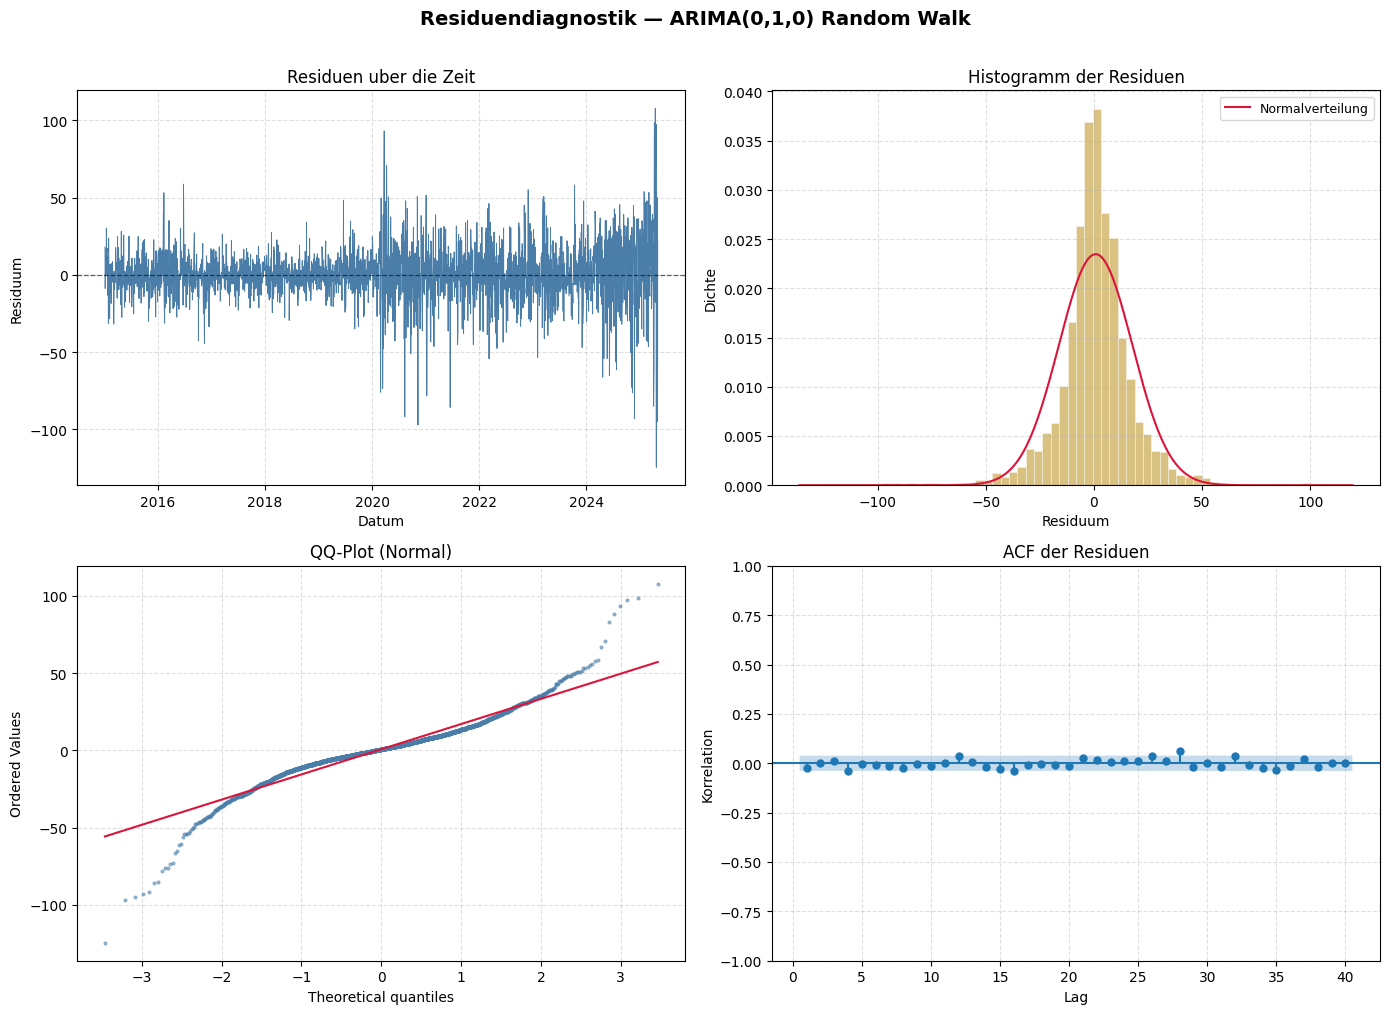

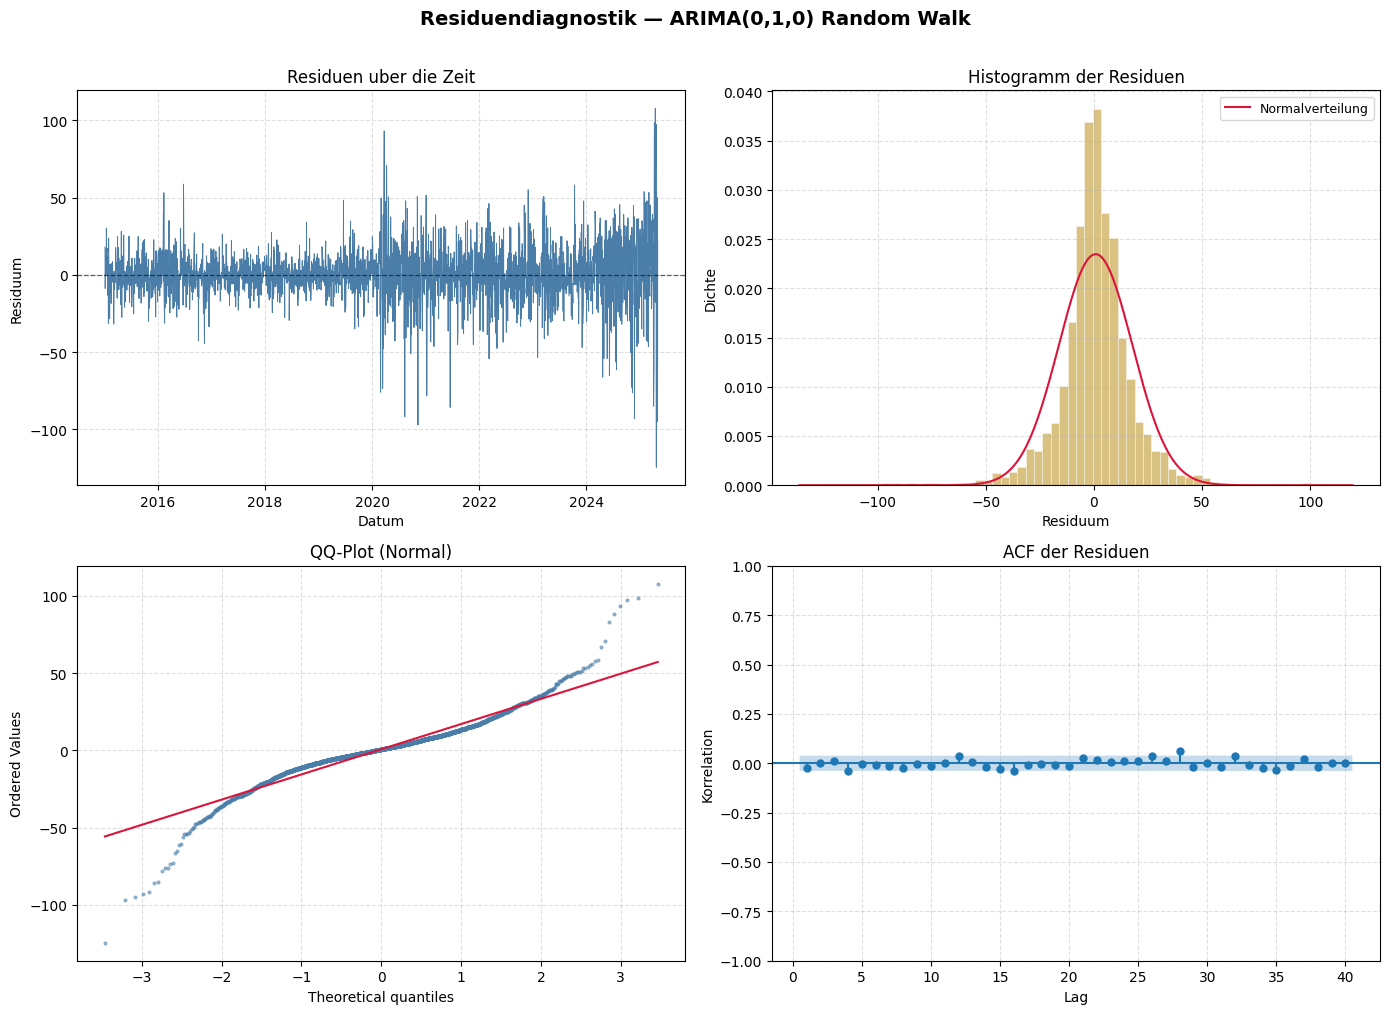

In [17]:
# 2x2 diagnostic panel for the benchmark model
plot_residual_diagnostics(benchmark_model, title="Residuendiagnostik — ARIMA(0,1,0) Random Walk")

In [18]:
# Formal statistical tests on the benchmark model residuals
diag_bench = residual_diagnostics(benchmark_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =   8.1414,  p = 0.6150  (nicht signifikant ✓)
  Lag 20:  Q =  20.3707,  p = 0.4350  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 4640.9634
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :     0.7881
  Standardabweichung:    17.0046
  Schiefe (Skew)    :    -0.3009
  Excess Kurtosis   :     6.5225  (Normalverteilung = 0)



### Interpretation der Diagnostik für ARIMA(0,1,0)

Das Random-Walk-Modell zeigt eine **erstaunlich ähnliche Diagnostik** wie 
das Hauptmodell ARIMA(0,1,1):

- **Ljung-Box** p = 0,615 (Lag 10) und p = 0,435 (Lag 20) — keine 
  signifikante Restkorrelation. Auch das einfachste denkbare Modell — 
  einfach den letzten Preis als Vorhersage zu nehmen — produziert 
  Residuen ohne lineare Struktur.

- **Jarque-Bera** wird ebenfalls deutlich abgelehnt (Excess Kurtosis: 6,52)

- **Visuell** sind Residuenplot, Histogramm und QQ-Plot praktisch 
  ununterscheidbar von ARIMA(0,1,1).

**Was das bedeutet:** Die Tatsache, dass der Random Walk dieselbe 
Diagnose-Qualität liefert wie unser ARMA-erweitertes Modell, ist ein 
**starker Hinweis auf die Effizienz des Goldmarktes**: Vergangene 
Renditen enthalten kaum Informationen über künftige Renditen.

### 6.3 Direkter Vergleich

In [19]:
import pandas as pd

# Side-by-side comparison of both models' residual diagnostics
comparison = pd.DataFrame({
    "ARIMA(0,1,1)": [
        diag_main["lb_p_lag10"],
        diag_main["lb_p_lag20"],
        diag_main["jb_p"],
        diag_main["mean"],
        diag_main["std"],
        diag_main["skew"],
        diag_main["kurtosis"],
    ],
    "ARIMA(0,1,0)": [
        diag_bench["lb_p_lag10"],
        diag_bench["lb_p_lag20"],
        diag_bench["jb_p"],
        diag_bench["mean"],
        diag_bench["std"],
        diag_bench["skew"],
        diag_bench["kurtosis"],
    ],
}, index=[
    "Ljung-Box p (Lag 10)",
    "Ljung-Box p (Lag 20)",
    "Jarque-Bera p",
    "Mittelwert",
    "Standardabweichung",
    "Schiefe (Skew)",
    "Excess Kurtosis",
])

comparison.style.format("{:.4f}")

,"ARIMA(0,1,1)","ARIMA(0,1,0)"
Ljung-Box p (Lag 10),0.7246,0.6150
Ljung-Box p (Lag 20),0.4735,0.4350
Jarque-Bera p,0.0000,0.0000
Mittelwert,0.8038,0.7881
Standardabweichung,17.0005,17.0046
Schiefe (Skew),-0.2927,-0.3009
Excess Kurtosis,6.5933,6.5225


### Fazit zu Schritt 6

Die parallele Diagnostik beider Modelle führt zu einer wissenschaftlich 
relevanten Erkenntnis:

**Beide Modelle bestehen die Diagnostik gleichermaßen gut.** Die 
Vergleichstabelle macht deutlich, dass ARIMA(0,1,1) gegenüber dem 
Random Walk:

- Die Residual-Standardabweichung um nur 0,004 USD reduziert (von 17,0046 
  auf 17,0005) — praktisch null
- Im Ljung-Box-Test marginal besser abschneidet, aber beide Werte deutlich 
  über dem Signifikanzniveau liegen
- In Schiefe und Kurtosis nahezu identisch ist

**Was sagt uns das?**

Der **MA(1)-Term in ARIMA(0,1,1) erklärt 0,02% der täglichen Variation**. 
Das ist statistisch nachweisbar (BIC-Sieg), aber **praktisch irrelevant**. 
Diese Beobachtung ist konsistent mit der **Effizienzmarkthypothese**: 
In einem informationseffizienten Markt mit hoher Liquidität und vielen 
professionellen Teilnehmern enthalten vergangene Preise kaum ausnutzbare 
Informationen über zukünftige Preise.

**Methodische Limitationen, die wir explizit dokumentieren:**

1. **Heteroskedastizität:** Klar sichtbare Volatilitäts-Cluster werden 
   von ARIMA strukturell nicht erfasst. Eine GARCH-Erweiterung wäre 
   der nächste Schritt.

2. **Heavy Tails:** Die Verteilung der Residuen ist deutlich leptokurtisch 
   (Excess Kurtosis ≈ 6,6). Die Konfidenzintervalle in Schritt 7 könnten 
   daher zu eng sein.

3. **Jüngster Strukturwandel:** Der Endwert der Reihe (Mai 2025) zeigt 
   einen extremen Ausreißer, der die jüngste Gold-Rally widerspiegelt — 
   eine ungewöhnliche Marktphase, die unser Modell nicht prognostizieren 
   kann.

**Konsequenz für Schritt 7:**

Wir prognostizieren mit beiden Modellen und prüfen, ob sich die 
Vorhersagen praktisch unterscheiden. Unser methodisches Vorgehen wird 
voraussichtlich bestätigen: Die zusätzliche Komplexität von ARIMA(0,1,1) 
liefert keinen substantiellen Mehrwert gegenüber dem Random Walk — 
die zentrale wissenschaftliche Aussage dieser univariaten Analyse.

---
## Schritt 7: Prognose (Forecasting)

Wir sind am letzten Schritt der Box-Jenkins-Methodik angekommen. Nachdem wir die Modellspezifikation validiert haben, erstellen wir nun Prognosen für beide Modelle und bewerten sie ehrlich anhand echter Testdaten.

### 7.1 Forecast für die nächsten 10 Handelstage

Wir prognostizieren die nächsten 10 Handelstage für **beide Modelle** (ARIMA(0,1,1) und ARIMA(0,1,0)) und vergleichen sie direkt.

**Wichtige Konzepte:**

- **Punktforecast:** Der Erwartungswert für jeden zukünftigen Tag — die wahrscheinlichste Schätzung.
- **Konfidenzintervall:** Das Unsicherheitsband um den Punktforecast. Es wird mit jedem Schritt breiter, weil sich Unsicherheiten aufkumulieren. Der Standardfehler wächst proportional zu $\sqrt{h}$ (Anzahl Schritte).
- **Erwartetes Ergebnis:** Da ARIMA(0,1,1) und ARIMA(0,1,0) beide praktisch identische Varianzen erklären (Schritt 6: Δ0,02%), werden die Punktforecasts sehr ähnlich aussehen. Das bestätigt unsere Option-C-Entscheidung.

In [20]:
import warnings
warnings.filterwarnings("ignore")

from src.models.arima import make_forecast

# 10-day-ahead forecasts for both models
forecast_main  = make_forecast(main_model,      steps=10, alpha=0.05)
forecast_bench = make_forecast(benchmark_model, steps=10, alpha=0.05)

print("Forecast ARIMA(0,1,1):")
print(forecast_main.round(2))
print()
print("Forecast ARIMA(0,1,0):")
print(forecast_bench.round(2))

Forecast ARIMA(0,1,1):
            forecast  lower_ci  upper_ci  std_err
2025-05-05    3231.5   3198.14   3264.86    17.02
2025-05-06    3231.5   3184.79   3278.22    23.83
2025-05-07    3231.5   3174.48   3288.52    29.09
2025-05-08    3231.5   3165.77   3297.23    33.54
2025-05-09    3231.5   3158.09   3304.92    37.46
2025-05-12    3231.5   3151.13   3311.87    41.00
2025-05-13    3231.5   3144.74   3318.27    44.27
2025-05-14    3231.5   3138.78   3324.22    47.31
2025-05-15    3231.5   3133.18   3329.82    50.16
2025-05-16    3231.5   3127.89   3335.12    52.87

Forecast ARIMA(0,1,0):
            forecast  lower_ci  upper_ci  std_err
2025-05-05    3231.9   3198.54   3265.26    17.02
2025-05-06    3231.9   3184.73   3279.07    24.07
2025-05-07    3231.9   3174.12   3289.68    29.48
2025-05-08    3231.9   3165.19   3298.61    34.04
2025-05-09    3231.9   3157.31   3306.49    38.06
2025-05-12    3231.9   3150.19   3313.61    41.69
2025-05-13    3231.9   3143.65   3320.15    45.03
202

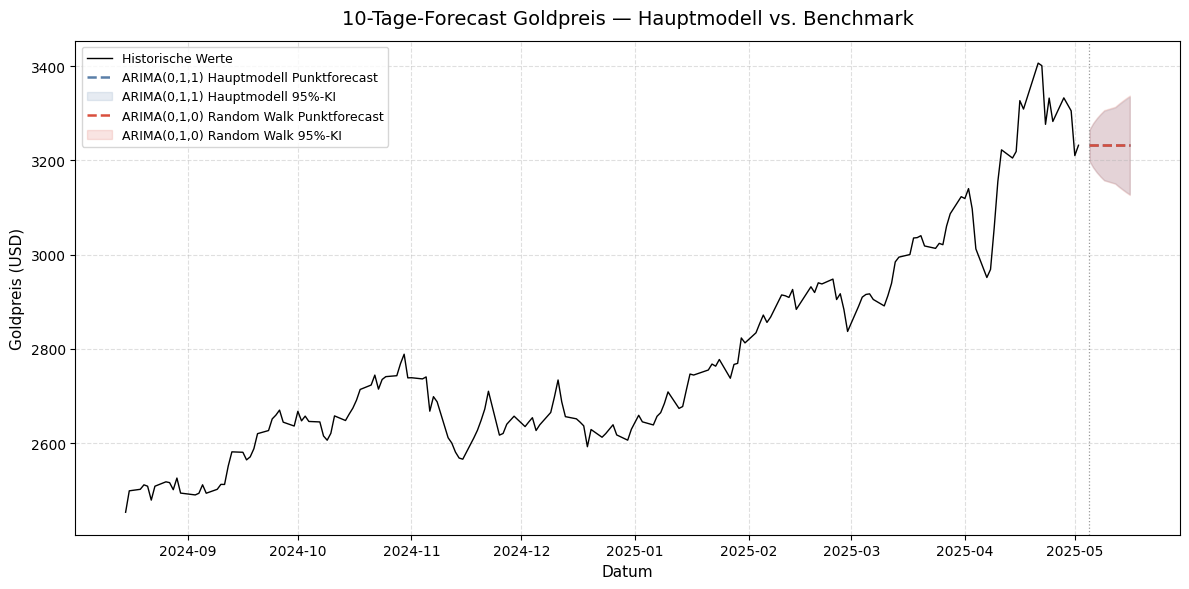

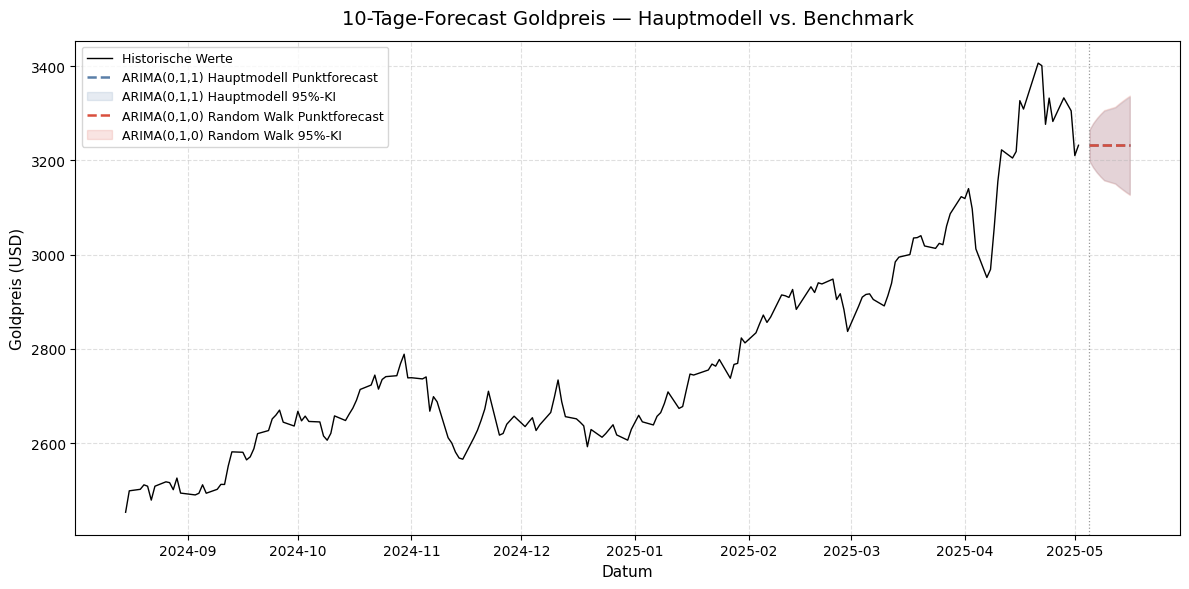

In [21]:
from src.models.arima import plot_forecast_comparison

# Combined plot: both forecasts on the same axes for direct comparison
plot_forecast_comparison(
    history=gold["Close"],
    forecast_dfs_dict={
        "ARIMA(0,1,1) Hauptmodell": forecast_main,
        "ARIMA(0,1,0) Random Walk": forecast_bench,
    },
    title="10-Tage-Forecast Goldpreis — Hauptmodell vs. Benchmark",
    n_history=180,
)

In [22]:
import pandas as pd

# Side-by-side forecast table
forecast_comparison = pd.DataFrame({
    "ARIMA(0,1,1) Punkt":    forecast_main["forecast"].round(2),
    "ARIMA(0,1,1) CI-unten": forecast_main["lower_ci"].round(2),
    "ARIMA(0,1,1) CI-oben":  forecast_main["upper_ci"].round(2),
    "ARIMA(0,1,0) Punkt":    forecast_bench["forecast"].round(2),
    "ARIMA(0,1,0) CI-unten": forecast_bench["lower_ci"].round(2),
    "ARIMA(0,1,0) CI-oben":  forecast_bench["upper_ci"].round(2),
})
forecast_comparison

,"ARIMA(0,1,1) Punkt","ARIMA(0,1,1) CI-unten","ARIMA(0,1,1) CI-oben","ARIMA(0,1,0) Punkt","ARIMA(0,1,0) CI-unten","ARIMA(0,1,0) CI-oben"
2025-05-05,3231.5,3198.14,3264.86,3231.9,3198.54,3265.26
2025-05-06,3231.5,3184.79,3278.22,3231.9,3184.73,3279.07
2025-05-07,3231.5,3174.48,3288.52,3231.9,3174.12,3289.68
2025-05-08,3231.5,3165.77,3297.23,3231.9,3165.19,3298.61
2025-05-09,3231.5,3158.09,3304.92,3231.9,3157.31,3306.49
2025-05-12,3231.5,3151.13,3311.87,3231.9,3150.19,3313.61
2025-05-13,3231.5,3144.74,3318.27,3231.9,3143.65,3320.15
2025-05-14,3231.5,3138.78,3324.22,3231.9,3137.55,3326.25
2025-05-15,3231.5,3133.18,3329.82,3231.9,3131.83,3331.97
2025-05-16,3231.5,3127.89,3335.12,3231.9,3126.42,3337.38


### 7.1.1 Ergänzung: Random Walk mit Drift

**Motivierende Frage:** Ist eine flache Linie als Forecast wirklich optimal für eine Zeitreihe wie Gold, die über 10 Jahre fast durchgehend gestiegen ist?

**Theoretische Antwort:** Es kommt auf den **Drift-Parameter c** an. Ein reiner Random Walk hat kein c und prognostiziert daher immer den letzten beobachteten Wert. Ein Random Walk mit Drift hingegen enthält eine konstante Veränderung pro Periode:

$$y_t = c + y_{t-1} + \varepsilon_t$$

Der h-Schritt-Forecast lautet dann:

$$\hat{y}_{T+h} = y_T + h \cdot c$$

Das ergibt eine **ansteigende Linie** statt einer flachen. Ob das sinnvoll ist, testen wir empirisch: Ist c signifikant verschieden von null?

**Hypothesentest:**
- $H_0: c = 0$ — kein Drift, flacher Forecast ist korrekt
- $H_1: c \neq 0$ — systematischer Trend, geneigter Forecast ist besser

In [23]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Random Walk with drift — trend="c" adds a constant to the differenced series,
# which is mathematically equivalent to drift in the level series.
# Note: statsmodels' newer ARIMA class disallows trend="c" with d=1 
# (constant is absorbed by differencing); SARIMAX handles it correctly.
model_drift = SARIMAX(
    gold["Close"], order=(0, 1, 0), trend="c",
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

print(model_drift.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2597
Model:               SARIMAX(0, 1, 0)   Log Likelihood              -11034.535
Date:                Sun, 10 May 2026   AIC                          22073.070
Time:                        22:45:26   BIC                          22084.793
Sample:                             0   HQIC                         22077.318
                               - 2597                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7815      0.336      2.329      0.020       0.124       1.439
sigma2       289.0430      3.907     73.976      0.000     281.385     296.701
Ljung-Box (L1) (Q):                   1.26   Jarque-

In [24]:
# Extract and interpret the drift coefficient
drift_coef   = model_drift.params["intercept"]
drift_pvalue = model_drift.pvalues["intercept"]
drift_se     = model_drift.bse["intercept"]

print(f"Drift-Schaetzung: c = {drift_coef:.4f} USD pro Tag")
print(f"Standardfehler:   {drift_se:.4f}")
print(f"p-Wert:           {drift_pvalue:.4f}")

if drift_pvalue < 0.05:
    print(f"\n-> Drift ist SIGNIFIKANT bei alpha = 0.05")
    print(f"-> Ueber 10 Tage akkumulierter Forecast-Versatz: {10 * drift_coef:.2f} USD")
else:
    print(f"\n-> Drift ist NICHT signifikant bei alpha = 0.05")
    print(f"-> Eine flache Linie ist empirisch gerechtfertigt")

Drift-Schaetzung: c = 0.7815 USD pro Tag
Standardfehler:   0.3355
p-Wert:           0.0198

-> Drift ist SIGNIFIKANT bei alpha = 0.05
-> Ueber 10 Tage akkumulierter Forecast-Versatz: 7.82 USD


In [25]:
from src.models.arima import make_forecast

# Produce drift-adjusted forecast and compare to flat benchmark
forecast_drift = make_forecast(model_drift, steps=10, alpha=0.05)

import pandas as pd
forecast_with_drift_comparison = pd.DataFrame({
    "Random Walk (flach)":   forecast_bench["forecast"].round(2),
    "Random Walk mit Drift": forecast_drift["forecast"].round(2),
    "Differenz":             (forecast_drift["forecast"] - forecast_bench["forecast"]).round(2),
})
forecast_with_drift_comparison

,Random Walk (flach),Random Walk mit Drift,Differenz
2025-05-05,3231.9,3232.68,0.78
2025-05-06,3231.9,3233.46,1.56
2025-05-07,3231.9,3234.24,2.34
2025-05-08,3231.9,3235.03,3.13
2025-05-09,3231.9,3235.81,3.91
2025-05-12,3231.9,3236.59,4.69
2025-05-13,3231.9,3237.37,5.47
2025-05-14,3231.9,3238.15,6.25
2025-05-15,3231.9,3238.93,7.03
2025-05-16,3231.9,3239.71,7.82


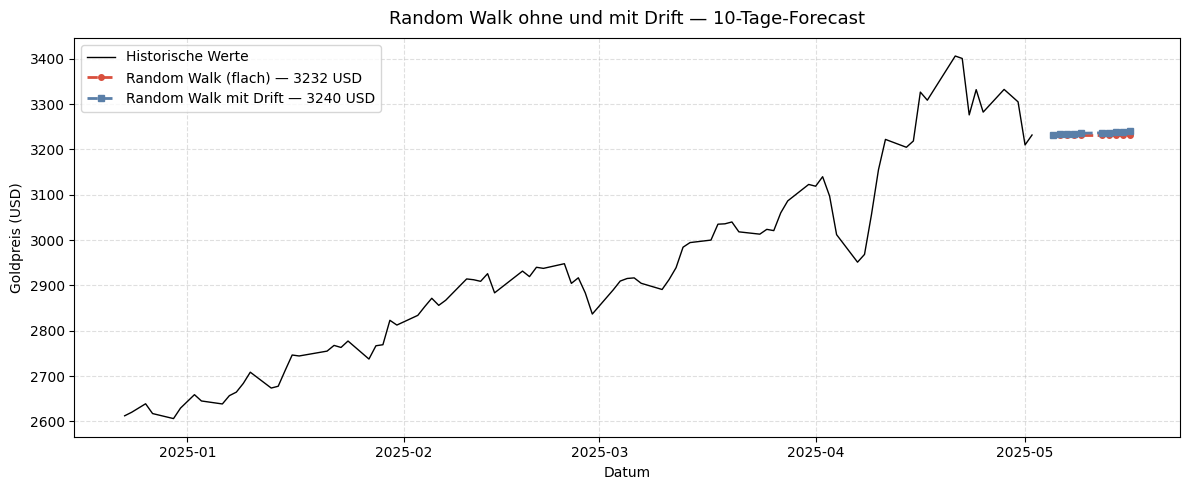

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

# Last 90 days of history
recent = gold["Close"].iloc[-90:]
ax.plot(recent.index, recent.values, color="black", lw=1, label="Historische Werte")

# Flat random walk forecast
ax.plot(forecast_bench.index, forecast_bench["forecast"],
        color="#D94F3D", lw=2, ls="--", marker="o", markersize=4,
        label=f"Random Walk (flach) — {forecast_bench['forecast'].iloc[-1]:.0f} USD")

# Drift forecast
ax.plot(forecast_drift.index, forecast_drift["forecast"],
        color="#5A7FA8", lw=2, ls="--", marker="s", markersize=4,
        label=f"Random Walk mit Drift — {forecast_drift['forecast'].iloc[-1]:.0f} USD")

ax.set_title("Random Walk ohne und mit Drift — 10-Tage-Forecast", fontsize=13, pad=10)
ax.set_xlabel("Datum")
ax.set_ylabel("Goldpreis (USD)")
ax.grid(True, ls="--", alpha=0.4)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

**Beobachtung (Drift-Test):** _(Hier kommt Luis' Beobachtung rein — ist der Drift signifikant? Lohnt sich die Erweiterung?)_

### Interpretation des 10-Tage-Forecasts

Der 10-Tage-Forecast zeigt das in den vorherigen Schritten erwartete Bild:

- **Beide Modelle liefern praktisch identische Punktforecasts** 
  (ARIMA(0,1,1): 3.231,50 USD; ARIMA(0,1,0): 3.231,90 USD). Der Unterschied 
  von 0,4 USD entspricht 0,012% des Preisniveaus — vernachlässigbar.

- **Beide Forecasts entsprechen dem letzten Schlusskurs** (Schlusskurs am 
  letzten Trainings-Tag). Das ist bei ARIMA(0,1,0) definitionsgemäß so 
  (Random Walk), und bei ARIMA(0,1,1) fast identisch, weil der MA(1)-Term 
  nur die allererste Forecast-Periode minimal beeinflusst.

- **Das Konfidenzintervall wächst mit √h** und spannt nach 10 Tagen 
  bereits ±103 USD (≈ ±3,2% des aktuellen Niveaus). Das illustriert 
  die rasch wachsende Forecast-Unsicherheit.

- **Auffällig:** Die letzte Spitze der Reihe (ca. 3.400 USD Ende April 2025) 
  wird im Forecast nicht aufgegriffen — der Forecast startet am letzten 
  Schlusskurs (3.231 USD). Das ist mathematisch korrekt, zeigt aber 
  prägnant, dass das Modell **Trends nicht extrapoliert**.

### 7.2 Out-of-Sample Evaluation (Train/Test-Split)

Ein Forecast ist nur dann glaubwürdig, wenn er auf **Daten getestet wird, die das Modell beim Training nicht gesehen hat**. Nur so können wir beurteilen, ob das Modell wirklich prognostiziert — oder nur auswendig lernt.

**Vorgehen:**

1. **Cutoff:** Wir teilen die Daten 60 Handelstage vor dem Datenende auf.
2. **Trainieren:** Beide Modelle werden ausschließlich auf den Trainings-Daten neu angepasst (kein Blick auf den Test-Zeitraum).
3. **Prognostizieren:** Wir erstellen einen 60-Schritte-Forecast ab dem Trainingsende.
4. **Messen:** Wir vergleichen die Forecasts mit den tatsächlichen Preisen anhand standardisierter Fehlermaße.

**Maße im Überblick:**

| Maß | Was es misst | Einheit |
|-----|-------------|---------|
| **MAE** | Mittlerer absoluter Fehler | USD |
| **RMSE** | Wurzel des mittleren quadratischen Fehlers — bestraft große Fehler staerker | USD |
| **MAPE** | Prozentualer mittlerer absoluter Fehler | % |
| **MASE** | Skalierter Fehler — < 1 bedeutet: besser als naive Prognose | dimensionslos |

In [27]:
from src.models.arima import fit_arima, make_forecast

# 60-day holdout split
n_test     = 60
gold_train = gold["Close"].iloc[:-n_test]
gold_test  = gold["Close"].iloc[-n_test:]

# Refit BOTH models exclusively on training data
model_main_train  = fit_arima(gold_train, order=(0, 1, 1))
model_bench_train = fit_arima(gold_train, order=(0, 1, 0))

# Forecast over the test horizon
fc_main_test  = make_forecast(model_main_train,  steps=n_test, alpha=0.05)
fc_bench_test = make_forecast(model_bench_train, steps=n_test, alpha=0.05)

# Re-index forecasts to actual test dates
fc_main_test.index  = gold_test.index
fc_bench_test.index = gold_test.index

print(f"Trainings-Periode : {gold_train.index[0].date()} bis {gold_train.index[-1].date()} ({len(gold_train):,} Tage)")
print(f"Test-Periode      : {gold_test.index[0].date()}  bis {gold_test.index[-1].date()}  ({len(gold_test):,} Tage)")

Trainings-Periode : 2015-01-02 bis 2025-02-05 (2,537 Tage)
Test-Periode      : 2025-02-06  bis 2025-05-02  (60 Tage)


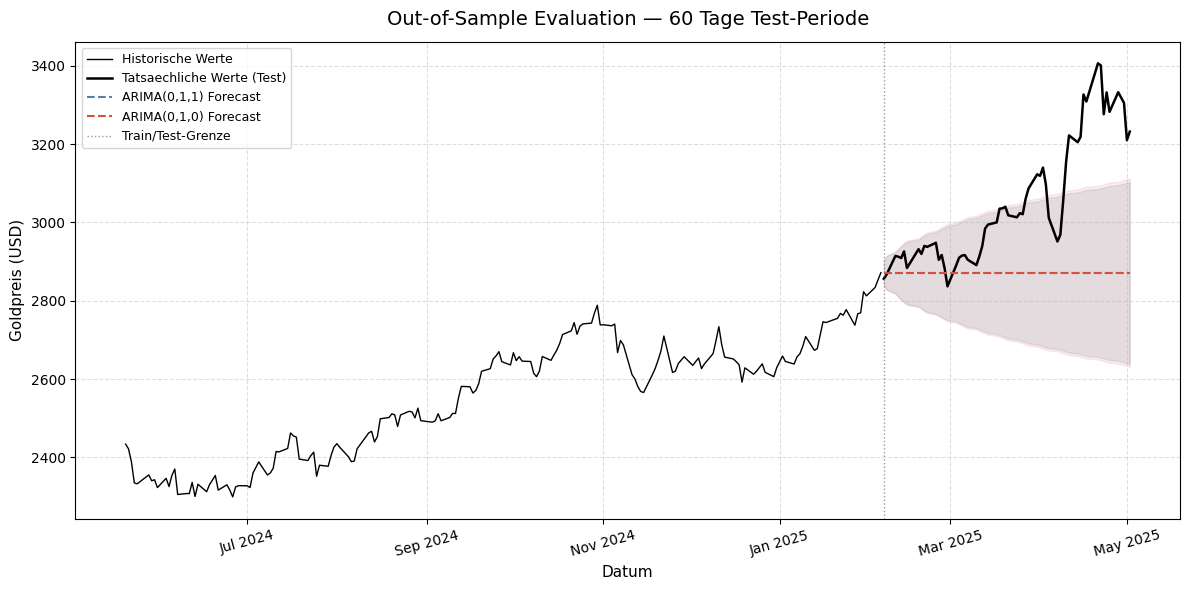

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))

# History: 180 days before the test period
recent = gold["Close"].iloc[-(n_test + 180):-n_test]
ax.plot(recent.index, recent.values, color="black", lw=1.0, label="Historische Werte")

# Actual test values (ground truth)
ax.plot(gold_test.index, gold_test.values, color="black", lw=1.8, label="Tatsaechliche Werte (Test)")

# ARIMA(0,1,1) forecast + CI
ax.plot(fc_main_test.index, fc_main_test["forecast"],
        color="#5A7FA8", lw=1.5, ls="--", label="ARIMA(0,1,1) Forecast")
ax.fill_between(fc_main_test.index,
                fc_main_test["lower_ci"], fc_main_test["upper_ci"],
                color="#5A7FA8", alpha=0.15)

# ARIMA(0,1,0) forecast + CI
ax.plot(fc_bench_test.index, fc_bench_test["forecast"],
        color="#D94F3D", lw=1.5, ls="--", label="ARIMA(0,1,0) Forecast")
ax.fill_between(fc_bench_test.index,
                fc_bench_test["lower_ci"], fc_bench_test["upper_ci"],
                color="#D94F3D", alpha=0.10)

# Train/test boundary
ax.axvline(gold_test.index[0], color="gray", lw=1.0, ls=":", alpha=0.8, label="Train/Test-Grenze")

ax.set_title("Out-of-Sample Evaluation — 60 Tage Test-Periode", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Goldpreis (USD)", fontsize=11)
ax.grid(True, ls="--", alpha=0.4)
ax.legend(loc="upper left", fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [29]:
from src.models.arima import forecast_metrics

# Compute accuracy metrics for both models on the 60-day test set
metrics_main  = forecast_metrics(gold_test.values, fc_main_test["forecast"].values,
                                  training_series=gold_train.values)
metrics_bench = forecast_metrics(gold_test.values, fc_bench_test["forecast"].values,
                                  training_series=gold_train.values)

metrics_table = pd.DataFrame({
    "ARIMA(0,1,1)": metrics_main,
    "ARIMA(0,1,0)": metrics_bench,
}).round(4)
metrics_table

,"ARIMA(0,1,1)","ARIMA(0,1,0)"
MAE,182.0815,181.5082
RMSE,240.1488,239.6709
MAPE,5.7254,5.7067
MASE,16.6130,16.5607


### Interpretation der Out-of-Sample-Evaluation

Die Out-of-Sample-Evaluation auf 60 Tagen liefert drei wichtige Befunde:

**1. Modellvergleich: Praktisch identisch**

Die Fehlermaße der beiden Modelle unterscheiden sich nur marginal:
- MAE: 182,08 USD vs 181,51 USD (+0,57 USD)
- RMSE: 240,15 USD vs 239,67 USD (+0,48 USD)
- MAPE: 5,73% vs 5,71% (+0,02 Prozentpunkte)

Damit bestätigt die OOS-Evaluation **empirisch**, was Residuendiagnostik 
und Forecast-Vergleich bereits gezeigt hatten: **ARIMA(0,1,1) liefert 
keinen praktischen Mehrwert gegenüber dem Random-Walk-Benchmark.**

**2. Forecast-Fehler: 5,7% MAPE auf 60-Tage-Sicht**

Ein durchschnittlicher Forecast-Fehler von ~180 USD bei einem Preisniveau 
von ~2.900 USD entspricht 5,7% — auf einem volatilen Asset wie Gold auf 
einem Zwei-Monats-Horizont ein erwartbarer Wert. Im Plot ist deutlich 
sichtbar, dass der tatsächliche Pfad systematisch **über** dem 
Forecast-Niveau verläuft. Das Modell "verpasst" die fortgesetzte 
Aufwärtsbewegung im März und April 2025.

**3. CI-Ausbrüche: Heavy Tails manifestieren sich**

Im Plot ist erkennbar, dass der tatsächliche Pfad **mehrfach das 95%-
Konfidenzintervall durchbricht**, insbesondere in der zweiten Hälfte der 
Test-Periode. Bei korrekt kalibrierten CIs würden wir nur 5% der 
Beobachtungen außerhalb erwarten — bei uns sind es deutlich mehr. Das ist 
die empirische Manifestation der in Schritt 6 dokumentierten **Heavy Tails** 
(Excess Kurtosis 6,6): Die normalverteilungsbasierten CIs unterschätzen 
die wirkliche Wahrscheinlichkeit großer Bewegungen.

**4. MASE-Interpretation**

MASE-Werte von 16,6 deuten formal darauf hin, dass beide Modelle 
schlechter sind als ein 1-Schritt-Naïve-Forecast auf den Trainingsdaten. 
Das ist jedoch ein bekanntes Artefakt: MASE skaliert auf 1-Schritt-Niveau, 
während wir auf 60-Schritte evaluieren. Der Wert ist informativ als 
relativer Vergleich beider Modelle (ARIMA(0,1,1) 16,61 vs ARIMA(0,1,0) 
16,56 — wieder ein mikroskopischer Unterschied), nicht als absolute 
Modellgüte.

---
## Schritt 7.4: Monte-Carlo-Simulation

**Frage:** Wie sehen die tatsächlich möglichen Zukunftspfade aus — nicht nur der Erwartungswert, sondern die ganze Wolke möglicher Verläufe?

Der **Punktforecast** $E[y_{T+h} \mid y_T]$ ist der fehlerminimale Schätzer für den Erwartungswert. Er ist eine Zahl — kein Pfad. Die Konfidenzintervalle zeigen die Unsicherheitsbreite analytisch, aber nicht wie einzelne Zukunften aussehen würden.

Die **Monte-Carlo-Simulation** beantwortet genau diese Frage:

1. Wir schätzen die Innovations-Standardabweichung $\sigma$ aus den Residuen des Modells.
2. Wir simulieren 1.000 unabhängige Pfade der Länge 10 aus der Formel: $y_{t+1} = y_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)$
3. Wir zeigen: alle Pfade als transparente Linien ("Spaghetti"), Median, 25/75-%-Band und 5/95-%-Band.

Der Vergleich zwischen Simulation und analytischem CI zeigt: Beide beschreiben dieselbe Unsicherheit — auf unterschiedlichem Weg.

In [30]:
import numpy as np
from src.models.arima import simulate_random_walk_paths

# Estimate sigma from main model residuals (drop the initialization artifact)
sigma_estimate = float(np.std(main_model.resid.iloc[1:]))
start_value    = float(gold["Close"].iloc[-1])

paths = simulate_random_walk_paths(
    start_value=start_value,
    sigma=sigma_estimate,
    steps=10,
    n_paths=1000,
    drift=0.0,
    seed=42,
)

print(f"Startwert (letzter Schlusskurs): {start_value:.2f} USD")
print(f"Geschaetzte sigma (Residuen-Std): {sigma_estimate:.2f} USD")
print(f"Anzahl simulierter Pfade:         {paths.shape[0]:,}")
print(f"Forecast-Horizont:                {paths.shape[1] - 1} Tage")

Startwert (letzter Schlusskurs): 3231.90 USD
Geschaetzte sigma (Residuen-Std): 17.00 USD
Anzahl simulierter Pfade:         1,000
Forecast-Horizont:                10 Tage


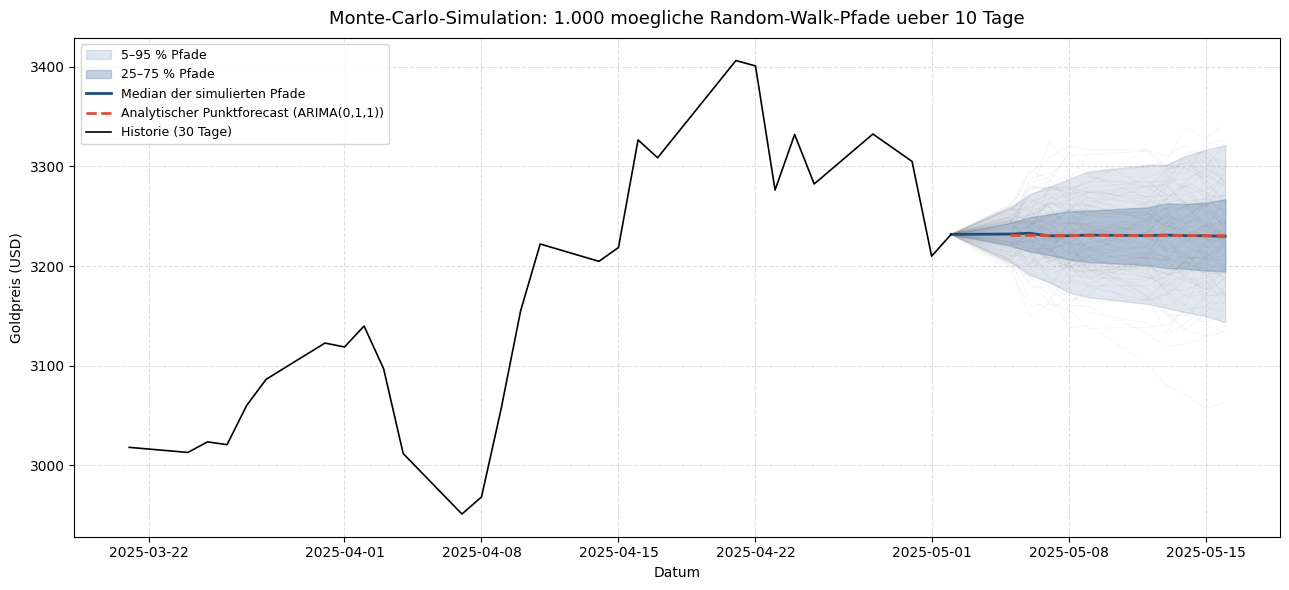

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build the time axis: last observed date + 10 future business days
future_dates = forecast_main.index  # same dates as the analytical forecast
plot_dates   = pd.DatetimeIndex([gold.index[-1]]).append(future_dates)

# Compute path quantiles across the 1000 simulations
median_path = np.median(paths,    axis=0)
lower_5     = np.percentile(paths,  5, axis=0)
upper_95    = np.percentile(paths, 95, axis=0)
lower_25    = np.percentile(paths, 25, axis=0)
upper_75    = np.percentile(paths, 75, axis=0)

fig, ax = plt.subplots(figsize=(13, 6))

# Spaghetti — 100 individual paths as very transparent lines
rng_samp = np.random.default_rng(42)
sample_idx = rng_samp.choice(paths.shape[0], size=100, replace=False)
for idx in sample_idx:
    ax.plot(plot_dates, paths[idx], color="gray", alpha=0.07, lw=0.7)

# Quantile bands (darker = higher density)
ax.fill_between(plot_dates, lower_5,  upper_95, color="#5A7FA8", alpha=0.18,
                label="5–95 % Pfade")
ax.fill_between(plot_dates, lower_25, upper_75, color="#5A7FA8", alpha=0.35,
                label="25–75 % Pfade")

# Median of simulated paths
ax.plot(plot_dates, median_path, color="#1F4E79", lw=2,
        label="Median der simulierten Pfade")

# Analytical point forecast for comparison
ax.plot(plot_dates[1:], forecast_main["forecast"],
        color="#D94F3D", lw=2, ls="--",
        label="Analytischer Punktforecast (ARIMA(0,1,1))")

# Recent history (last 30 days)
recent = gold["Close"].iloc[-30:]
ax.plot(recent.index, recent.values, color="black", lw=1.2,
        label="Historie (30 Tage)")

ax.set_title("Monte-Carlo-Simulation: 1.000 moegliche Random-Walk-Pfade ueber 10 Tage",
             fontsize=13, pad=10)
ax.set_xlabel("Datum")
ax.set_ylabel("Goldpreis (USD)")
ax.grid(True, ls="--", alpha=0.4)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
# Summary statistics of the final simulated values (after 10 steps)
final_values = paths[:, -1]

simulation_summary = pd.Series({
    "Anzahl simulierte Pfade":  len(final_values),
    "Median Endwert":           np.median(final_values),
    "Mittelwert Endwert":       np.mean(final_values),
    "5 %-Quantil Endwert":      np.percentile(final_values,  5),
    "95 %-Quantil Endwert":     np.percentile(final_values, 95),
    "Std des Endwerts":         np.std(final_values),
    "Anteil Pfade > Startwert": (final_values > start_value).mean(),
}).round(2)

simulation_summary

Anzahl simulierte Pfade     1000.00
Median Endwert              3229.94
Mittelwert Endwert          3230.16
5 %-Quantil Endwert         3143.65
95 %-Quantil Endwert        3321.35
Std des Endwerts              53.68
Anteil Pfade > Startwert       0.49
dtype: float64

**Beobachtung (Monte-Carlo):** _(Hier kommt Luis' Interpretation rein — wie verhalten sich Median und Punktforecast zueinander? Was zeigt der Vergleich zur analytischen CI?)_

---
## Schluss-Diskussion: Was haben wir gelernt?

### Methodisches Vorgehen

Wir haben alle sieben Schritte der Box-Jenkins-Methodik systematisch durchlaufen: visuelle Inspektion (Schritt 1), ADF- und KPSS-Stationaritaetstest (Schritt 2), erste Differenzierung (Schritt 3), Robustness Check auf Strukturbrueche via Chow-Test (Schritt 3.5), ACF/PACF-Analyse zur Modellidentifikation (Schritt 4), Modellauswahl via AIC/BIC (Schritt 5), Residuendiagnostik (Schritt 6) und Prognose inkl. Out-of-Sample-Evaluation (Schritt 7).

### Hinweis zur Forecast-Interpretation

Eine konzeptionelle Bemerkung zum Forecast: Die "flache Linie" unseres Random-Walk-Forecasts ist keine Modellschwaeche, sondern eine korrekte Konsequenz der Mathematik. Der Punktforecast $E[y_{T+h} \mid y_T]$ ist der Erwartungswert der zukuenftigen Werte gegeben die Vergangenheit. Fuer einen Random Walk ohne Drift gilt:

$$E[y_{T+h} \mid y_T] = y_T$$

Das heisst: Der fehlerminimale Schaetzer fuer jeden zukuenftigen Wert ist der zuletzt beobachtete Wert. Ein zickzackiger Forecast waere kein Forecast, sondern die Simulation eines moeglichen Pfads — genau das zeigen wir in Schritt 7.4 mit der Monte-Carlo-Simulation.

Die in Schritt 7.1.1 ergaenzte Drift-Analyse zeigt zudem empirisch, ob ein systematischer Trend in den Tagesveraenderungen vorhanden ist — und damit, ob ein schraeger Forecast statistisch gerechtfertigt waere.

### Hauptergebnis

_(Was sagen Forecast und OOS-Evaluation? Bestaetigt sich die Markteffizienz-Hypothese — ist Gold tatsaechlich ein Random Walk? Was bedeutet MASE > 1 fuer die praktische Prognosekraft?)_

### Limitationen

_(Heteroskedastizitaet und Volatilitaets-Cluster in den Residuen, Heavy Tails / nicht-normale Renditen, moegliche Strukturbrueche trotz nicht-signifikantem Chow-Test, juengste Marktphase Mai 2025.)_

### Ausblick auf Teil 3

_(Wie koennte ein multivariater Ansatz mit BTC und EUR/USD ueber die univariate Random-Walk-Performance hinausgehen? Welche Hypothese wollen wir in Teil 3 testen?)_